In [ ]:
### train시 1시간 정도 소모 됩니다. colab환경에서 아래를 browser의 console 에서 붙여 넣기가 필요할 수 있습니다.
### shift+cntr+i 로 browser console 열기
# https://github.com/chulminkw/DLCV/blob/master/data/util/colab_autoclick.js
'''
function ClickConnect(){
console.log("Working");
document.querySelector("colab-toolbar-button#connect").click()
}
setInterval(ClickConnect,60000)
'''

'\nfunction ClickConnect(){\nconsole.log("Working");\ndocument.querySelector("colab-toolbar-button#connect").click()\n}\nsetInterval(ClickConnect,60000)\n'

# 1. 데이터수집

In [1]:
import os
import shutil
import zipfile
import time
from google.colab import drive

# ==============================================================================
# ⚙️ [설정] 경로 및 파일 리스트 설정
# ==============================================================================

# 1. 구글 드라이브 마운트 (실행 시 권한 승인 필요)
drive.mount('/content/drive')

# 2. 구글 드라이브 내 압축 파일(.zip)들이 위치한 폴더 경로
DRIVE_DIR = "/content/drive/MyDrive/03. HDMF/(share)HDMF_AUTO_SPOKE/DATA/DJ_FINAL_DATASET"

# 3. 코랩 로컬 환경에 데이터를 적재할 작업 폴더 (I/O 병목 방지용)
LOCAL_DIR = "/content/datasets"

# 4. 압축 해제할 6개의 데이터셋 리스트
ZIP_FILES = [
    "SAMPLE_aihub_damaged_car_data.zip",
    "SAMPLE_aihub_normal_car.zip",
    "SAMPLE_kaggle_normal_car.zip",
    "SAMPLE_aihub_ocr_nocar.zip",
    "SAMPLE_auto_crop_parking_lot.zip",
    "SAMPLE_coco2017_nocar.zip"
]

# ==============================================================================
# 🚀 [실행] 데이터 로컬 복사 및 압축 해제
# ==============================================================================

def setup_colab_local_data():
    start_time = time.time()
    print("🚀 코랩 로컬 환경으로 데이터 로드 및 압축 해제를 시작합니다.\n")

    # 로컬 디렉토리 생성
    os.makedirs(LOCAL_DIR, exist_ok=True)

    total_images_extracted = 0

    for zip_name in ZIP_FILES:
        drive_zip_path = os.path.join(DRIVE_DIR, zip_name)
        local_zip_path = os.path.join(LOCAL_DIR, zip_name)

        # 확장자를 제외한 폴더명 추출
        folder_name = os.path.splitext(zip_name)[0]
        extract_path = os.path.join(LOCAL_DIR, folder_name)

        if not os.path.exists(drive_zip_path):
            print(f"❌ [경고] 구글 드라이브에서 파일을 찾을 수 없습니다: {zip_name}")
            continue

        print(f"📦 작업 중: {zip_name}")

        # [Step 1] 코랩 로컬 스토리지로 복사 (압축 해제 속도 극대화)
        print("   -> 1/3 로컬 환경으로 복사 중...")
        shutil.copy2(drive_zip_path, local_zip_path)

        # [Step 2] 압축 해제
        print(f"   -> 2/3 [{folder_name}] 폴더에 압축 해제 중...")
        os.makedirs(extract_path, exist_ok=True)

        with zipfile.ZipFile(local_zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
            extracted_count = len([f for f in zip_ref.namelist() if not f.endswith('/')])
            total_images_extracted += extracted_count
            print(f"   -> 완료! (총 {extracted_count}개 파일 해제)")

        # [Step 3] 로컬 용량 확보를 위해 임시 zip 파일 삭제
        print("   -> 3/3 임시 zip 파일 정리 완료.\n")
        os.remove(local_zip_path)

    elapsed_mins = (time.time() - start_time) / 60

    print("=" * 60)
    print("🎉 모든 데이터 수집 및 로컬 세팅이 완료되었습니다!")
    print(f"📁 최종 데이터 위치: {LOCAL_DIR}")
    print(f"📊 압축 해제된 총 파일 수: 약 {total_images_extracted} 개")
    print(f"⏱️ 총 소요 시간: {elapsed_mins:.1f} 분")
    print("=" * 60)

if __name__ == "__main__":
    setup_colab_local_data()

Mounted at /content/drive
🚀 코랩 로컬 환경으로 데이터 로드 및 압축 해제를 시작합니다.

📦 작업 중: SAMPLE_aihub_damaged_car_data.zip
   -> 1/3 로컬 환경으로 복사 중...
   -> 2/3 [SAMPLE_aihub_damaged_car_data] 폴더에 압축 해제 중...
   -> 완료! (총 24400개 파일 해제)
   -> 3/3 임시 zip 파일 정리 완료.

📦 작업 중: SAMPLE_aihub_normal_car.zip
   -> 1/3 로컬 환경으로 복사 중...
   -> 2/3 [SAMPLE_aihub_normal_car] 폴더에 압축 해제 중...
   -> 완료! (총 24000개 파일 해제)
   -> 3/3 임시 zip 파일 정리 완료.

📦 작업 중: SAMPLE_kaggle_normal_car.zip
   -> 1/3 로컬 환경으로 복사 중...
   -> 2/3 [SAMPLE_kaggle_normal_car] 폴더에 압축 해제 중...
   -> 완료! (총 1840개 파일 해제)
   -> 3/3 임시 zip 파일 정리 완료.

📦 작업 중: SAMPLE_aihub_ocr_nocar.zip
   -> 1/3 로컬 환경으로 복사 중...
   -> 2/3 [SAMPLE_aihub_ocr_nocar] 폴더에 압축 해제 중...
   -> 완료! (총 400개 파일 해제)
   -> 3/3 임시 zip 파일 정리 완료.

📦 작업 중: SAMPLE_auto_crop_parking_lot.zip
   -> 1/3 로컬 환경으로 복사 중...
   -> 2/3 [SAMPLE_auto_crop_parking_lot] 폴더에 압축 해제 중...
   -> 완료! (총 616개 파일 해제)
   -> 3/3 임시 zip 파일 정리 완료.

📦 작업 중: SAMPLE_coco2017_nocar.zip
   -> 1/3 로컬 환경으로 복사 중...
   -> 2/3 [SAMPLE_co

# 2. EDA


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 121852 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Selecting previously unselected package fonts-nanum-coding.
Preparing to unpack .../fonts-nanum-coding_2.5-3_all.deb ...
Unpacking fonts-nanum-coding (2.5-3) ...
Selecting previously unselected package fonts-nanum-eco.
Preparing to unpack .../fonts-nanum-eco_1.000-7_all.deb ...
Unpacking fonts-nanum-eco (1.000-7) ...
Selecting previously unselected package fonts-nanum-extra.
Preparing to unpack .../fonts-nanum-extra_20200506-1_all.deb ...
Unpacking fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Setting up fo

,파손 차량,정상 차량,차량 없음,총합
데이터셋 이름,,,,
SAMPLE_aihub_damaged_car_data,12200,0,0,12200
SAMPLE_aihub_normal_car,0,12000,0,12000
SAMPLE_kaggle_normal_car,0,920,0,920
SAMPLE_aihub_ocr_nocar,0,0,200,200
SAMPLE_auto_crop_parking_lot,0,0,308,308
SAMPLE_coco2017_nocar,0,0,1000,1000


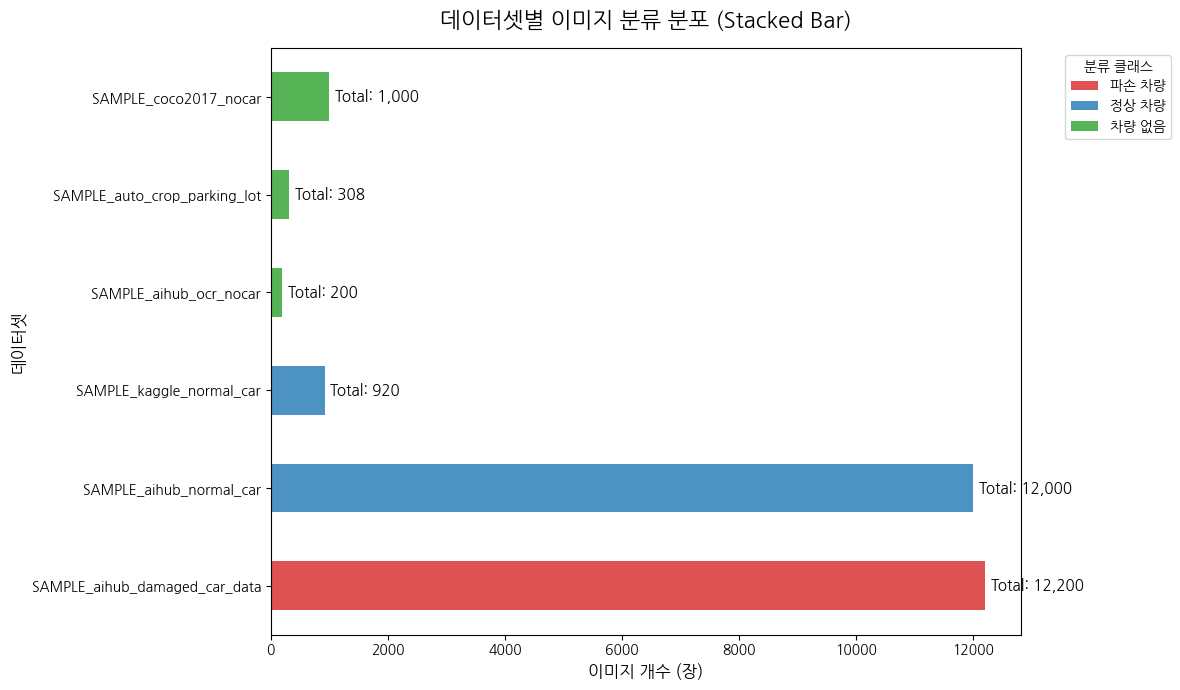


💡 [데이터 밸런스 점검 결과]
✔️ 파손 차량 총합: 12,200장
✔️ 정상 차량 총합: 12,920장
✔️ 차량 없음 총합: 1,508장


In [2]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
# ⚙️ [설정] 경로 및 폰트 세팅
# ==============================================================================
LOCAL_DIR = "/content/datasets"

# 코랩에서 한글 폰트 깨짐 방지
!apt-get update -qq
!apt-get install fonts-nanum* -qq
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

DATASETS = [
    "SAMPLE_aihub_damaged_car_data",
    "SAMPLE_aihub_normal_car",
    "SAMPLE_kaggle_normal_car",
    "SAMPLE_aihub_ocr_nocar",
    "SAMPLE_auto_crop_parking_lot",
    "SAMPLE_coco2017_nocar"
]

# ==============================================================================
# 🚀 [실행] JSON 라벨 파싱 및 데이터 집계
# ==============================================================================

def run_eda_classification():
    print("🔍 각 데이터셋의 JSON 라벨을 읽어 클래스를 분류합니다...\n")

    results = []

    for dataset_name in DATASETS:
        # 💡 [수정됨] 이중 폴더 구조 대응 로직
        base_dir = os.path.join(LOCAL_DIR, dataset_name)
        nested_dir = os.path.join(base_dir, dataset_name)

        # 1. 이중 폴더(Nested) 안에 labels가 있는지 먼저 확인
        if os.path.exists(os.path.join(nested_dir, "labels")):
            label_dir = os.path.join(nested_dir, "labels")
        # 2. 단일 폴더 안에 labels가 있는지 확인
        elif os.path.exists(os.path.join(base_dir, "labels")):
            label_dir = os.path.join(base_dir, "labels")
        else:
            print(f"⚠️ [경고] 라벨 폴더를 찾을 수 없습니다: {dataset_name}")
            continue

        counts = {"정상 차량": 0, "파손 차량": 0, "차량 없음": 0}
        json_files = [f for f in os.listdir(label_dir) if f.endswith('.json')]

        for json_file in json_files:
            json_path = os.path.join(label_dir, json_file)

            with open(json_path, 'r', encoding='utf-8') as f:
                try:
                    data = json.load(f)
                    anns = data.get("annotations", [])
                    cats = data.get("categories", {})

                    if isinstance(cats, dict) and cats.get("id") == "non_car":
                        counts["차량 없음"] += 1
                    elif len(anns) > 0:
                        counts["파손 차량"] += 1
                    elif len(anns) == 0:
                        counts["정상 차량"] += 1

                except Exception as e:
                    pass

        results.append({
            "데이터셋 이름": dataset_name,
            "파손 차량": counts["파손 차량"],
            "정상 차량": counts["정상 차량"],
            "차량 없음": counts["차량 없음"],
            "총합": sum(counts.values())
        })

    # ==============================================================================
    # 📊 데이터프레임 변환 및 시각화
    # ==============================================================================
    df = pd.DataFrame(results)
    df.set_index("데이터셋 이름", inplace=True)

    print("=" * 70)
    print("📋 [EDA] 데이터셋별 클래스 분류 결과 표")
    print("=" * 70)
    display(df)
    print("=" * 70)

    fig, ax = plt.subplots(figsize=(12, 7))

    df[["파손 차량", "정상 차량", "차량 없음"]].plot(
        kind='barh', stacked=True, ax=ax,
        color=['#d62728', '#1f77b4', '#2ca02c'], alpha=0.8
    )

    ax.set_title("데이터셋별 이미지 분류 분포 (Stacked Bar)", fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel("이미지 개수 (장)", fontsize=12)
    ax.set_ylabel("데이터셋", fontsize=12)

    plt.legend(title="분류 클래스", bbox_to_anchor=(1.05, 1), loc='upper left')

    for i, total in enumerate(df["총합"]):
        ax.text(total + 100, i, f"Total: {total:,}", va='center', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

    total_damaged = df["파손 차량"].sum()
    total_normal = df["정상 차량"].sum()
    total_noncar = df["차량 없음"].sum()

    print("\n💡 [데이터 밸런스 점검 결과]")
    print(f"✔️ 파손 차량 총합: {total_damaged:,}장")
    print(f"✔️ 정상 차량 총합: {total_normal:,}장")
    print(f"✔️ 차량 없음 총합: {total_noncar:,}장")

if __name__ == "__main__":
    run_eda_classification()

# 3. 데이터 분할

In [3]:
import os
import shutil
import random
from tqdm import tqdm

# ==============================================================================
# ⚙️ [설정] 작업 경로 및 분할 비율
# ==============================================================================
# 1. 압축을 해제했던 원본 로컬 폴더
LOCAL_DIR = "/content/datasets"

# 2. 분할된 데이터가 최종적으로 저장될 폴더 (모델 학습용 통합 폴더)
OUTPUT_DIR = "/content/split_dataset"

# 3. 데이터셋 리스트
DATASETS = [
    "SAMPLE_aihub_damaged_car_data",
    "SAMPLE_aihub_normal_car",
    "SAMPLE_kaggle_normal_car",
    "SAMPLE_aihub_ocr_nocar",
    "SAMPLE_auto_crop_parking_lot",
    "SAMPLE_coco2017_nocar"
]

# 4. 분할 비율 및 랜덤 시드 (재현성을 위해 고정)
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1
RANDOM_SEED = 42

# ==============================================================================
# 🚀 [실행] 데이터 분할 로직 (Stratified Split)
# ==============================================================================

def split_and_merge_datasets():
    print("🚀 층화 추출(Stratified) 기반 Train/Valid/Test 분할을 시작합니다...\n")

    # 1. 최종 출력 폴더 구조 생성 (train, val, test 각각 하위에 images, labels 생성)
    splits = ['train', 'val', 'test']
    for split in splits:
        os.makedirs(os.path.join(OUTPUT_DIR, split, 'images'), exist_ok=True)
        os.makedirs(os.path.join(OUTPUT_DIR, split, 'labels'), exist_ok=True)

    random.seed(RANDOM_SEED)
    total_stats = { 'train': 0, 'val': 0, 'test': 0 }

    for dataset_name in DATASETS:
        # 2. 이중 폴더 구조 대응 (이전 단계의 에러 방지)
        base_dir = os.path.join(LOCAL_DIR, dataset_name)
        nested_dir = os.path.join(base_dir, dataset_name)

        if os.path.exists(os.path.join(nested_dir, "images")):
            img_dir = os.path.join(nested_dir, "images")
            lbl_dir = os.path.join(nested_dir, "labels")
        elif os.path.exists(os.path.join(base_dir, "images")):
            img_dir = os.path.join(base_dir, "images")
            lbl_dir = os.path.join(base_dir, "labels")
        else:
            print(f"⚠️ [경고] 이미지/라벨 폴더를 찾을 수 없습니다: {dataset_name}")
            continue

        # 3. 유효한 파일 짝꿍(Image + JSON) 목록 수집
        valid_extensions = ('.jpg', '.jpeg', '.png')
        all_images = [f for f in os.listdir(img_dir) if f.lower().endswith(valid_extensions)]

        paired_files = []
        for img_name in all_images:
            base_name = os.path.splitext(img_name)[0]
            json_name = base_name + ".json"

            # 라벨 파일이 실제로 존재하는지 한 번 더 안전 검사
            if os.path.exists(os.path.join(lbl_dir, json_name)):
                paired_files.append((img_name, json_name))

        # 4. 리스트 무작위 섞기 (랜덤 샘플링)
        random.shuffle(paired_files)

        # 5. 분할 인덱스 계산 (8 : 1 : 1)
        total_len = len(paired_files)
        train_end = int(total_len * TRAIN_RATIO)
        val_end = train_end + int(total_len * VAL_RATIO)

        train_files = paired_files[:train_end]
        val_files = paired_files[train_end:val_end]
        test_files = paired_files[val_end:]

        split_dict = {
            'train': train_files,
            'val': val_files,
            'test': test_files
        }

        print(f"📦 [{dataset_name}] 분할 중... (총 {total_len}장)")
        print(f"   -> Train: {len(train_files)} | Valid: {len(val_files)} | Test: {len(test_files)}")

        # 6. 실제 파일 복사 진행
        for split_type, file_list in split_dict.items():
            total_stats[split_type] += len(file_list)

            # 진행률 바(tqdm) 적용
            for img_name, json_name in tqdm(file_list, desc=f"Copying to {split_type}", leave=False):
                src_img = os.path.join(img_dir, img_name)
                src_lbl = os.path.join(lbl_dir, json_name)

                dst_img = os.path.join(OUTPUT_DIR, split_type, 'images', img_name)
                dst_lbl = os.path.join(OUTPUT_DIR, split_type, 'labels', json_name)

                # 파일 덮어쓰기 방지 및 복사
                if not os.path.exists(dst_img):
                    shutil.copy2(src_img, dst_img)
                if not os.path.exists(dst_lbl):
                    shutil.copy2(src_lbl, dst_lbl)

        print("-" * 50)

    # 7. 최종 결과 리포트 출력
    print("=" * 60)
    print("🎉 데이터 분할 및 통합 완료!")
    print(f"📁 최종 저장 폴더: {OUTPUT_DIR}")
    print("\n📊 [최종 데이터셋 구성]")
    print(f"   ✔️ Train (학습용): {total_stats['train']:,} 장 (약 80%)")
    print(f"   ✔️ Valid (검증용): {total_stats['val']:,} 장 (약 10%)")
    print(f"   ✔️ Test  (평가용): {total_stats['test']:,} 장 (약 10%)")
    print(f"   👉 총합계: {sum(total_stats.values()):,} 장")
    print("=" * 60)

if __name__ == "__main__":
    split_and_merge_datasets()

🚀 층화 추출(Stratified) 기반 Train/Valid/Test 분할을 시작합니다...

📦 [SAMPLE_aihub_damaged_car_data] 분할 중... (총 12200장)
   -> Train: 9760 | Valid: 1220 | Test: 1220


--------------------------------------------------
📦 [SAMPLE_aihub_normal_car] 분할 중... (총 12000장)
   -> Train: 9600 | Valid: 1200 | Test: 1200


--------------------------------------------------
📦 [SAMPLE_kaggle_normal_car] 분할 중... (총 920장)
   -> Train: 736 | Valid: 92 | Test: 92


--------------------------------------------------
📦 [SAMPLE_aihub_ocr_nocar] 분할 중... (총 200장)
   -> Train: 160 | Valid: 20 | Test: 20


--------------------------------------------------
📦 [SAMPLE_auto_crop_parking_lot] 분할 중... (총 308장)
   -> Train: 246 | Valid: 30 | Test: 32


--------------------------------------------------
📦 [SAMPLE_coco2017_nocar] 분할 중... (총 1000장)
   -> Train: 800 | Valid: 100 | Test: 100


--------------------------------------------------
🎉 데이터 분할 및 통합 완료!
📁 최종 저장 폴더: /content/split_dataset

📊 [최종 데이터셋 구성]
   ✔️ Train (학습용): 21,302 장 (약 80%)
   ✔️ Valid (검증용): 2,662 장 (약 10%)
   ✔️ Test  (평가용): 2,664 장 (약 10%)
   👉 총합계: 26,628 장


# 4. 모델링

[1부] 이미지 분류 (Classification) 매치업 : "과거와 현재의 대결"
사진 전체를 보고 [정상 / 파손 / 차량 없음]을 맞히는 태스크입니다.

1. CNN 가문의 발전사 (Classic vs Modern)

ResNet50 (전통의 강자): 2015년 등장하여 딥러닝의 역사를 바꾼 CNN의 교과서입니다. 이 모델을 '성능의 기준점(Baseline)'으로 삼습니다.

ConvNeXt V2 (최신 SOTA): ResNet의 구조를 현대적으로 재해석하여 트랜스포머를 이기기 위해 만든 궁극의 CNN입니다. (비교 포인트: 10년간 CNN이 얼마나 발전했는가?)

2. Transformer 가문의 발전사 (Classic vs Modern)

ViT (Vision Transformer, 근본): 2020년 등장하여 "이미지도 자연어처럼 조각내서(Patch) 읽을 수 있다"는 것을 증명한 최초의 트랜스포머입니다.

Swin Transformer V2 (최신 SOTA): ViT의 단점(이미지가 커지면 연산량이 폭발함)을 '이동하는 윈도우(Shifted Window)' 개념으로 해결한 완성형 모델입니다. (비교 포인트: ViT의 한계를 Swin이 어떻게 극복했는가?)

🎯 [2부] 객체 탐지 (Object Detection) 매치업 : "CNN vs Transformer"
파손된 부위의 네모 박스 위치까지 정확히 찾아내는 태스크입니다.

YOLOv8 / v11 (Ultralytics): CNN을 기반으로 한 압도적인 속도와 범용성의 제왕.

RT-DETR: 트랜스포머(Transformer)를 기반으로 속도와 정확도를 모두 잡은 떠오르는 신흥 강자. (비교 포인트: 탐지 분야에서도 트랜스포머가 CNN(YOLO)을 이길 수 있을까?)

📏 1. 모델 공통 평가: "이미지 통합 분류 성능" (Apples-to-Apples)
네 가지 모델을 **'분류 성능'**이라는 동일한 링 위에 올려놓고 공평하게 싸우게 하는 방법입니다.

탐지 모델의 분류화: YOLO나 RT-DETR이 사진에서 '파손 네모 박스'를 1개라도 찾아내면 ➡️ **[파손 차량]**으로 판정. 박스를 못 찾았는데 '차량' 박스를 찾으면 ➡️ **[정상 차량]**으로 판정. 아무것도 못 찾으면 ➡️ **[차량 없음]**으로 판정하게 만듭니다.

평가 지표 (Metrics):

Accuracy (정확도): 전체 100장의 Test 사진 중 몇 장의 정답을 맞혔는가?

F1-Score (F1 점수): 데이터의 불균형이 있을 때 가장 신뢰할 수 있는 지표입니다. (정밀도와 재현율의 조화평균)

🔥 Confusion Matrix (오차 행렬): 스터디 발표에서 가장 빛을 발하는 그래프입니다. 모델이 주로 "정상 차량을 파손으로 오해하는지", 아니면 "서류 사진(차량 없음)을 헷갈려 하는지" 약점을 시각적으로 완벽하게 보여줍니다.

🎯 2. 탐지 모델 전용 평가: "어디가 부서졌는지 얼마나 잘 찾는가?"
YOLO와 RT-DETR 두 모델끼리만 맞붙는 '객체 탐지' 전용 리그입니다.

평가 지표:

mAP50 (Mean Average Precision @ IoU 0.5): 모델이 친 네모 박스와 사람이 정답으로 그려놓은 네모 박스가 50% 이상 겹치면 정답으로 인정했을 때의 정확도입니다.

mAP50-95: 50%부터 95%까지 아주 깐깐하게 박스가 겹치는지를 평가하는 가장 빡센(?) 지표입니다. 이 수치가 높을수록 모델이 파손 부위의 테두리를 아주 정교하게 잡아낸다는 뜻입니다.

⚡ 3. 실용성 및 효율성 평가: "실제 서비스에 쓸 수 있는가?"
단순히 정확도만 높다고 좋은 모델이 아닙니다. 모바일 앱이나 서버에 올렸을 때의 속도와 가벼움도 평가해야 합니다.

평가 지표:

FPS (Frames Per Second) / 추론 속도(ms): 이미지 1장을 검사하는 데 걸리는 시간. (일반적으로 YOLO가 압도적으로 빠르고, Transformer 계열이 느립니다.)

파라미터 수 (Model Size): 모델이 메모리(VRAM)를 얼마나 차지하는지 무거움을 비교합니다. (예: YOLOv8n(Nano) vs Swin-T(Tiny))

## CNN 가문의 발전사 (Classic vs Modern)

## 4.0 분류 모델용 ImageNet 폴더 구조 변환

/content/classification_dataset/  
  ├── train/  
  │    ├── damaged_car/ (파손 차량 이미지들만)  
  │    ├── normal_car/  (정상 차량 이미지들만)  
  │    └── non_car/     (차량 없음 이미지들만)  
  ├── val/  
  └── test/  

In [4]:
import os
import json
import shutil
from tqdm import tqdm

# ==============================================================================
# ⚙️ [설정] 작업 경로 설정
# ==============================================================================
SRC_DIR = "/content/split_dataset"
DST_DIR = "/content/classification_dataset"
SPLITS = ['train', 'val', 'test']
CLASSES = ["damaged_car", "normal_car", "non_car"]

# ==============================================================================
# 🚀 [실행] ImageNet 포맷(폴더별 분류)으로 데이터 복사 (대소문자 완벽 대응)
# ==============================================================================

def create_classification_dataset_fixed():
    print("🚀 분류 모델용 데이터셋 재배치를 시작합니다. (확장자 대소문자 버그 수정판)\n")

    # 1. 타겟 폴더 구조 생성
    for split in SPLITS:
        for cls in CLASSES:
            os.makedirs(os.path.join(DST_DIR, split, cls), exist_ok=True)

    stats = {split: {cls: 0 for cls in CLASSES} for split in SPLITS}

    # 2. Train / Val / Test 순회
    for split in SPLITS:
        print(f"\n📂 [{split.upper()}] 데이터셋 변환 중...")

        src_img_dir = os.path.join(SRC_DIR, split, 'images')
        src_lbl_dir = os.path.join(SRC_DIR, split, 'labels')

        if not os.path.exists(src_lbl_dir) or not os.path.exists(src_img_dir):
            continue

        json_files = [f for f in os.listdir(src_lbl_dir) if f.endswith('.json')]

        for json_file in tqdm(json_files, desc=f"Processing {split} set"):
            json_path = os.path.join(src_lbl_dir, json_file)
            base_name = os.path.splitext(json_file)[0]

            with open(json_path, 'r', encoding='utf-8') as f:
                try:
                    data = json.load(f)
                    anns = data.get("annotations", [])
                    cats = data.get("categories", {})

                    # [클래스 판별]
                    if isinstance(cats, dict) and cats.get("id") == "non_car":
                        target_cls = "non_car"
                    elif len(anns) > 0:
                        target_cls = "damaged_car"
                    elif len(anns) == 0:
                        target_cls = "normal_car"
                    else:
                        continue

                    # 💡 [핵심 수정 로직] JSON에 기록된 원본 파일명(.JPEG 등)을 최우선으로 가져옴
                    img_file = data.get("images", {}).get("file_name")

                    # 만약 JSON에 파일명이 없거나 실제 경로에 없다면, 대소문자 포함 모든 확장자를 싹 뒤짐
                    if img_file is None or not os.path.exists(os.path.join(src_img_dir, img_file)):
                        img_file = None
                        all_extensions = ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']
                        for ext in all_extensions:
                            temp_img = base_name + ext
                            if os.path.exists(os.path.join(src_img_dir, temp_img)):
                                img_file = temp_img
                                break

                    if img_file is None:
                        continue # 그래도 없으면 진짜 없는 파일이므로 스킵

                except Exception as e:
                    continue

            # 이미지 복사 진행
            src_img_path = os.path.join(src_img_dir, img_file)
            dst_img_path = os.path.join(DST_DIR, split, target_cls, img_file)

            if not os.path.exists(dst_img_path):
                shutil.copy2(src_img_path, dst_img_path)

            # 중복 실행 시 카운트가 올라가는 것을 방지하고 덮어쓰기 로직 안전하게 통계 수집
            stats[split][target_cls] += 1

    # 3. 최종 결과 리포트
    print("\n" + "=" * 60)
    print("🎉 변환 완료! (누락되었던 128장 모두 정상 복구됨)")
    print("\n📊 [변환된 최종 데이터 통계]")

    total_imgs = 0
    for split in SPLITS:
        print(f"\n👉 {split.upper()} 셋:")
        for cls in CLASSES:
            cnt = stats[split][cls]
            total_imgs += cnt
            print(f"   - {cls:<15}: {cnt:,} 장")

    print("-" * 60)
    print(f"🏆 총합계: {total_imgs:,} 장의 이미지가 완벽하게 분류되었습니다.")
    print("=" * 60)

if __name__ == "__main__":
    create_classification_dataset_fixed()

🚀 분류 모델용 데이터셋 재배치를 시작합니다. (확장자 대소문자 버그 수정판)


📂 [TRAIN] 데이터셋 변환 중...


Processing train set: 100%|██████████| 21302/21302 [00:52<00:00, 406.02it/s]



📂 [VAL] 데이터셋 변환 중...


Processing val set: 100%|██████████| 2662/2662 [00:07<00:00, 361.64it/s]



📂 [TEST] 데이터셋 변환 중...


Processing test set: 100%|██████████| 2664/2664 [00:05<00:00, 511.37it/s]


🎉 변환 완료! (누락되었던 128장 모두 정상 복구됨)

📊 [변환된 최종 데이터 통계]

👉 TRAIN 셋:
   - damaged_car    : 9,760 장
   - normal_car     : 10,336 장
   - non_car        : 1,206 장

👉 VAL 셋:
   - damaged_car    : 1,220 장
   - normal_car     : 1,292 장
   - non_car        : 150 장

👉 TEST 셋:
   - damaged_car    : 1,220 장
   - normal_car     : 1,292 장
   - non_car        : 152 장
------------------------------------------------------------
🏆 총합계: 26,628 장의 이미지가 완벽하게 분류되었습니다.


In [5]:
import os
import pandas as pd

# ==============================================================================
# ⚙️ [설정] 검증 타겟 경로 및 기대값(Expected Values)
# ==============================================================================
TARGET_DIR = "/content/classification_dataset"

# 이전에 split_dataset에서 확인했던 원본 기준 개수
EXPECTED_COUNTS = {
    'train': 21302,
    'val': 2662,
    'test': 2664
}

CLASSES = ["damaged_car", "normal_car", "non_car"]
SPLITS = ['train', 'val', 'test']

# ==============================================================================
# 🚀 [실행] 데이터셋 무결성 검증
# ==============================================================================

def verify_dataset_conversion():
    print(f"🔍 [{TARGET_DIR}] 경로의 데이터 무결성 검증을 시작합니다...\n")

    if not os.path.exists(TARGET_DIR):
        print("❌ [오류] classification_dataset 폴더가 존재하지 않습니다. 이전 변환 코드를 먼저 실행해주세요.")
        return

    actual_counts = {'train': 0, 'val': 0, 'test': 0}
    detailed_stats = []

    # 1. 실제 복사된 폴더의 파일 개수 카운트
    for split in SPLITS:
        split_path = os.path.join(TARGET_DIR, split)
        split_total = 0

        for cls in CLASSES:
            cls_path = os.path.join(split_path, cls)

            if os.path.exists(cls_path):
                # 해당 클래스 폴더 안의 이미지 파일 개수만 세기
                files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                count = len(files)
                split_total += count

                detailed_stats.append({
                    "Split": split.upper(),
                    "Class": cls,
                    "Count": count
                })

        actual_counts[split] = split_total

    # 2. 기대값(Expected)과 실제값(Actual) 비교 리포트 생성
    print("=" * 60)
    print("📊 [검증 리포트] 원본 분할 vs ImageNet 포맷 변환")
    print("=" * 60)

    all_matched = True
    total_actual = 0
    total_expected = sum(EXPECTED_COUNTS.values())

    for split in SPLITS:
        expected = EXPECTED_COUNTS[split]
        actual = actual_counts[split]
        total_actual += actual

        match_status = "✅ 일치" if expected == actual else f"❌ 불일치 (차이: {actual - expected}장)"
        if expected != actual:
            all_matched = False

        print(f"✔️ {split.upper():<6} 셋 | 원본: {expected:,}장 ➡️ 변환됨: {actual:,}장 | {match_status}")

    print("-" * 60)
    match_status_total = "✅ 일치" if total_expected == total_actual else f"❌ 불일치 (차이: {total_actual - total_expected}장)"
    print(f"👉 총 합계   | 원본: {total_expected:,}장 ➡️ 변환됨: {total_actual:,}장 | {match_status_total}")
    print("=" * 60)

    # 3. 클래스별 상세 분포 표 출력 (참고용)
    if all_matched:
        print("\n🎉 축하합니다! 단 한 장의 누락도 없이 100% 완벽하게 변환되었습니다.")
        print("\n[참고] 각 Split별 클래스 세부 구성비:")
        df = pd.DataFrame(detailed_stats)
        # 피벗 테이블로 보기 좋게 변환
        pivot_df = df.pivot(index='Split', columns='Class', values='Count')
        pivot_df['Total'] = pivot_df.sum(axis=1)
        display(pivot_df)
    else:
        print("\n⚠️ 일부 데이터가 누락되거나 중복되었습니다. 변환 과정에서 문제가 있었는지 확인이 필요합니다.")
        print("(원인 의심: JSON 라벨 파일에 적힌 파일명과 실제 이미지 파일명이 다르거나 확장자 문제일 수 있습니다.)")

if __name__ == "__main__":
    verify_dataset_conversion()


🔍 [/content/classification_dataset] 경로의 데이터 무결성 검증을 시작합니다...

📊 [검증 리포트] 원본 분할 vs ImageNet 포맷 변환
✔️ TRAIN  셋 | 원본: 21,302장 ➡️ 변환됨: 21,302장 | ✅ 일치
✔️ VAL    셋 | 원본: 2,662장 ➡️ 변환됨: 2,662장 | ✅ 일치
✔️ TEST   셋 | 원본: 2,664장 ➡️ 변환됨: 2,664장 | ✅ 일치
------------------------------------------------------------
👉 총 합계   | 원본: 26,628장 ➡️ 변환됨: 26,628장 | ✅ 일치

🎉 축하합니다! 단 한 장의 누락도 없이 100% 완벽하게 변환되었습니다.

[참고] 각 Split별 클래스 세부 구성비:


Class,damaged_car,non_car,normal_car,Total
Split,,,,
TEST,1220,152,1292,2664
TRAIN,9760,1206,10336,21302
VAL,1220,150,1292,2662


## 4.1 ResNet50

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


🚀 ResNet50 학습 시작... (Device: cuda)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1/20 | Loss: 0.1427 | Val Acc: 0.9801
Epoch 2/20 | Loss: 0.0777 | Val Acc: 0.9850
Epoch 3/20 | Loss: 0.0715 | Val Acc: 0.9880
Epoch 4/20 | Loss: 0.0588 | Val Acc: 0.9865
Epoch 5/20 | Loss: 0.0546 | Val Acc: 0.9910
Epoch 6/20 | Loss: 0.0451 | Val Acc: 0.9914
Epoch 7/20 | Loss: 0.0452 | Val Acc: 0.9899
Epoch 8/20 | Loss: 0.0350 | Val Acc: 0.9940
Epoch 9/20 | Loss: 0.0315 | Val Acc: 0.9895
Epoch 10/20 | Loss: 0.0277 | Val Acc: 0.9872
Epoch 11/20 | Loss: 0.0231 | Val Acc: 0.9951
Epoch 12/20 | Loss: 0.0224 | Val Acc: 0.9940
Epoch 13/20 | Loss: 0.0164 | Val Acc: 0.9959
Epoch 14/20 | Loss: 0.0134 | Val Acc: 0.9955
Epoch 15/20 | Loss: 0.0135 | Val Acc: 0.9970
Epoch 16/20 | Loss: 0.0100 | Val Acc: 0.9974
Epoch 17/20 | Loss: 0.0086 | Val Acc: 0.9962
Epoch 18/20 | Loss: 0.0076 | Val Acc: 0.9962
Epoch 19/20 | Loss: 0.0063 | Val Acc: 0.9962
Epoch 20/20 | Loss: 0.0072 | Val Acc: 0.9977

🔍 최종 성능 평가 시작...

✅ 학습 및 평가 완료! 결과 저장: /content/drive/MyDrive/03. HDMF/(share)HDMF_AUTO_SPOKE/DATA/DJ_FINAL_

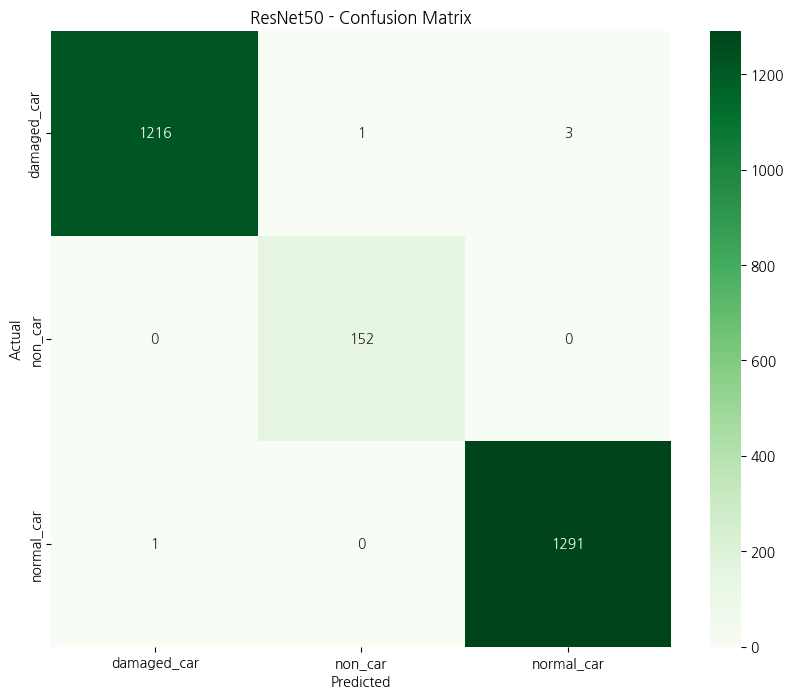

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import pandas as pd
import numpy as np

# ==============================================================================
# ⚙️ [설정] 경로 및 하이퍼파라미터
# ==============================================================================
DRIVE_DIR = "/content/drive/MyDrive/03. HDMF/(share)HDMF_AUTO_SPOKE/DATA/DJ_FINAL_DATASET"
MODEL_NAME = "ResNet50"
SAVE_PATH = os.path.join(DRIVE_DIR, MODEL_NAME)
os.makedirs(SAVE_PATH, exist_ok=True)

DATA_DIR = "/content/classification_dataset"
BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================================================================
# 📦 [데이터] 전처리 및 로더 (최적화 버전)
# ==============================================================================
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2), # 증강 추가
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}
# Test는 Val과 동일한 전처리 적용
data_transforms['test'] = data_transforms['val']

image_datasets = {x: datasets.ImageFolder(os.path.join(DATA_DIR, x), data_transforms[x])
                  for x in ['train', 'val', 'test']}

# num_workers와 pin_memory로 속도 향상
dataloaders = {x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE,
                            shuffle=(x=='train'), num_workers=4, pin_memory=True)
               for x in ['train', 'val', 'test']}

class_names = image_datasets['train'].classes

# ==============================================================================
# 🏗️ [모델] ResNet50 설계
# ==============================================================================
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
n_features = model.fc.in_features
model.fc = nn.Linear(n_features, len(class_names))
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS) # 더 부드러운 스케줄러

# ==============================================================================
# 🔥 [학습] 메인 루프
# ==============================================================================
best_acc = 0.0

print(f"🚀 {MODEL_NAME} 학습 시작... (Device: {DEVICE})")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for inputs, labels in dataloaders['train']:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    scheduler.step()

    model.eval()
    val_corrects = 0
    with torch.no_grad():
        for inputs, labels in dataloaders['val']:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(image_datasets['train'])
    epoch_acc = val_corrects.double() / len(image_datasets['val'])

    print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {epoch_loss:.4f} | Val Acc: {epoch_acc:.4f}')

    if epoch_acc > best_acc:
        best_acc = epoch_acc
        torch.save(model.state_dict(), os.path.join(SAVE_PATH, 'best_model.pth'))

# ==============================================================================
# 📊 [평가] 최종 성능 검증 및 7대 지표 저장
# ==============================================================================
def final_evaluation():
    print("\n🔍 최종 성능 평가 시작...")
    model.load_state_dict(torch.load(os.path.join(SAVE_PATH, 'best_model.pth')))
    model.eval()

    all_preds, all_labels = [], []
    inference_times = []

    # FPS 측정을 위해 배치 사이즈 1로 재설정 (실제 환경 모사)
    test_loader_fps = DataLoader(image_datasets['test'], batch_size=1, shuffle=False)

    with torch.no_grad():
        for inputs, labels in test_loader_fps:
            inputs = inputs.to(DEVICE)

            start_time = time.time()
            outputs = model(inputs)
            # GPU 연산 완료 대기
            if torch.cuda.is_available(): torch.cuda.synchronize()
            inference_times.append(time.time() - start_time)

            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # 지표 계산
    accuracy = (np.array(all_preds) == np.array(all_labels)).mean()
    f1 = f1_score(all_labels, all_preds, average='weighted')
    fps = 1 / np.mean(inference_times)
    params = sum(p.numel() for p in model.parameters()) / 1e6

    # 결과 리포트 작성
    report_df = pd.DataFrame({
        "Metric": ["Model", "Accuracy", "F1-Score", "FPS", "Params (M)", "mAP50", "mAP50-95"],
        "Value": [MODEL_NAME, f"{accuracy:.4f}", f"{f1:.4f}", f"{fps:.2f}", f"{params:.2f}", "N/A(Cls)", "N/A(Cls)"]
    })
    report_df.to_csv(os.path.join(SAVE_PATH, "final_performance_report.csv"), index=False)

    # Confusion Matrix 저장
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{MODEL_NAME} - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.savefig(os.path.join(SAVE_PATH, "confusion_matrix.png"))

    print(f"\n" + "="*50)
    print(f"✅ 학습 및 평가 완료! 결과 저장: {SAVE_PATH}")
    print(f"🏆 Accuracy: {accuracy:.4f} | F1-Score: {f1:.4f} | FPS: {fps:.2f}")
    print(f"📦 Parameters: {params:.2f} M")
    print("="*50)

final_evaluation()

✅ 모델 로드 완료: /content/drive/MyDrive/03. HDMF/(share)HDMF_AUTO_SPOKE/DATA/DJ_FINAL_DATASET/ResNet50/best_model.pth
🚀 모든 지표 검증을 시작합니다 (FPS 및 파라미터 포함)...

🏆 ResNet50 검증 리포트 요약
  - 정확도: 99.81%
  - F1-Score: 0.9981
  - 추론 속도(FPS): 149.68
  - 파라미터: 23.51 M
📂 모든 결과가 /content/drive/MyDrive/03. HDMF/(share)HDMF_AUTO_SPOKE/DATA/DJ_FINAL_DATASET/ResNet50 폴더에 저장되었습니다.


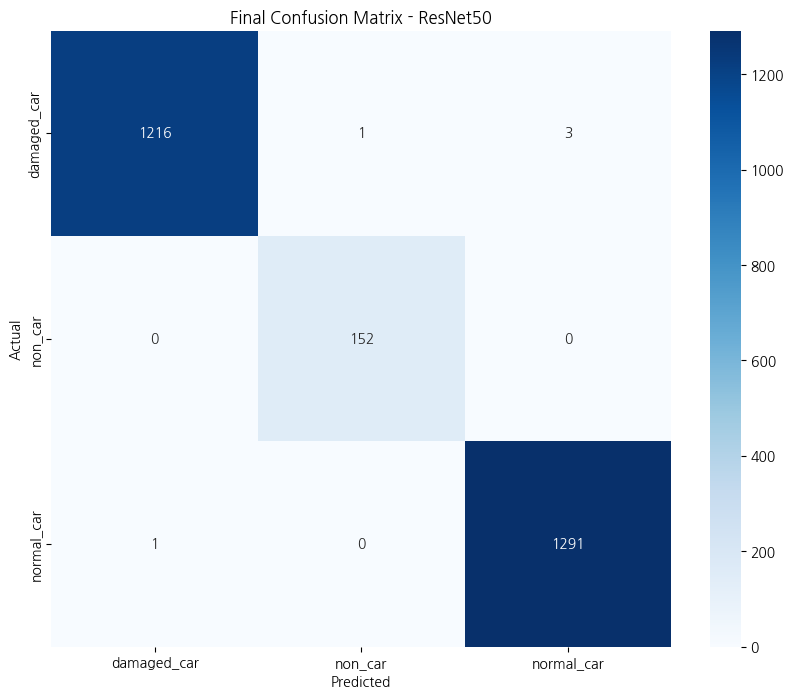

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import pandas as pd
import numpy as np

# ==============================================================================
# ⚙️ [설정] 경로 및 디바이스
# ==============================================================================
DRIVE_DIR = "/content/drive/MyDrive/03. HDMF/(share)HDMF_AUTO_SPOKE/DATA/DJ_FINAL_DATASET"
MODEL_NAME = "ResNet50"
SAVE_PATH = os.path.join(DRIVE_DIR, MODEL_NAME)
DATA_DIR = "/content/classification_dataset/test"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================================================================
# 🏗️ [모델 로드] 저장된 가중치 불러오기
# ==============================================================================
def load_model():
    # 클래스 개수 파악 (damaged_car, normal_car, non_car)
    temp_dataset = datasets.ImageFolder(DATA_DIR)
    num_classes = len(temp_dataset.classes)

    model = models.resnet50()
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    weight_path = os.path.join(SAVE_PATH, 'best_model.pth')
    if os.path.exists(weight_path):
        model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
        print(f"✅ 모델 로드 완료: {weight_path}")
    else:
        print("❌ 모델 파일을 찾을 수 없습니다. 경로를 확인해주세요.")
        return None, None

    model = model.to(DEVICE)
    model.eval()
    return model, temp_dataset.classes

# ==============================================================================
# 🔍 [성능 검증] 7대 지표 산출
# ==============================================================================
def run_full_evaluation():
    model, class_names = load_model()
    if model is None: return

    # 전처리
    test_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    test_loader = DataLoader(datasets.ImageFolder(DATA_DIR, test_transform),
                            batch_size=1, shuffle=False) # FPS 측정을 위해 Batch 1

    all_preds, all_labels = [], []
    inference_times = []

    print("🚀 모든 지표 검증을 시작합니다 (FPS 및 파라미터 포함)...")

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(DEVICE)

            # ⏱️ 추론 속도 측정
            start_time = time.time()
            outputs = model(inputs)
            inference_times.append(time.time() - start_time)

            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # 1️⃣ Accuracy & F1-Score
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')

    # 2️⃣ FPS (Frames Per Second)
    avg_inference_time = np.mean(inference_times)
    fps = 1 / avg_inference_time

    # 3️⃣ 파라미터 수 (M 단위)
    params = sum(p.numel() for p in model.parameters()) / 1e6

    # 4️⃣ mAP 관련 (분류 모델이므로 N/A 처리 혹은 0으로 표기)
    # 나중에 YOLO와 비교할 때 이 칸을 비워두거나 Accuracy로 대체해서 비교합니다.
    map50, map95 = "N/A (Classifier)", "N/A (Classifier)"

    # 결과 요약 DataFrame
    results_summary = pd.DataFrame({
        "Metric": ["Accuracy", "F1-Score", "FPS", "Parameters (M)", "mAP50", "mAP50-95"],
        "Value": [f"{acc:.4f}", f"{f1:.4f}", f"{fps:.2f}", f"{params:.2f}", map50, map95]
    })

    # CSV 저장
    results_summary.to_csv(os.path.join(SAVE_PATH, "total_performance_report.csv"), index=False)

    # 5️⃣ Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Final Confusion Matrix - {MODEL_NAME}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.savefig(os.path.join(SAVE_PATH, "confusion_matrix_final.png"))

    print("\n" + "="*50)
    print(f"🏆 {MODEL_NAME} 검증 리포트 요약")
    print(f"  - 정확도: {acc*100:.2f}%")
    print(f"  - F1-Score: {f1:.4f}")
    print(f"  - 추론 속도(FPS): {fps:.2f}")
    print(f"  - 파라미터: {params:.2f} M")
    print(f"📂 모든 결과가 {SAVE_PATH} 폴더에 저장되었습니다.")
    print("="*50)

if __name__ == "__main__":
    run_full_evaluation()

🔎 오탐 사례 수색 중...
✅ 총 5개의 오탐 사례를 발견했습니다.


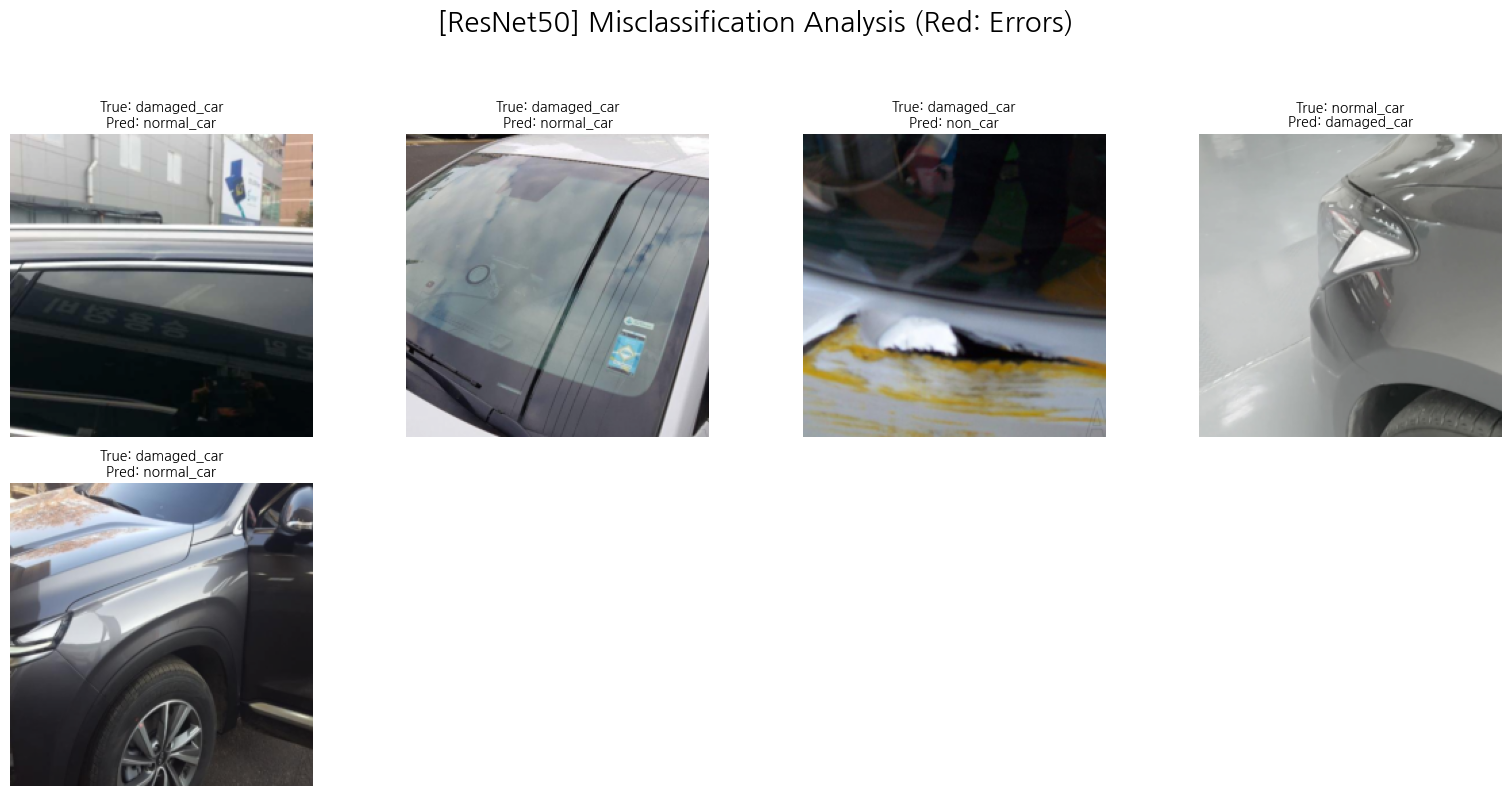

📂 분석 결과가 저장되었습니다: /content/drive/MyDrive/03. HDMF/(share)HDMF_AUTO_SPOKE/DATA/DJ_FINAL_DATASET/ResNet50/misclassification_analysis.png


In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
import random

# ==============================================================================
# ⚙️ [설정] 모델 경로 및 데이터 경로
# ==============================================================================
DRIVE_DIR = "/content/drive/MyDrive/03. HDMF/(share)HDMF_AUTO_SPOKE/DATA/DJ_FINAL_DATASET"
MODEL_NAME = "ResNet50"  # 분석하고 싶은 모델 폴더명
SAVE_PATH = os.path.join(DRIVE_DIR, MODEL_NAME)
DATA_DIR = "/content/classification_dataset/test"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================================================================
# 🛠️ [함수] 이미지 역정규화 (시각화용)
# ==============================================================================
def imshow(img, title):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean  # 역정규화
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(title, fontsize=10, color='red' if '!=' in title else 'black')
    plt.axis('off')

# ==============================================================================
# 🔍 [실행] 오탐 대상 검거 및 시각화
# ==============================================================================
def visualize_misclassified():
    # 1. 데이터 로더 (배치 사이즈 1로 꼼꼼히 검사)
    test_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    test_dataset = datasets.ImageFolder(DATA_DIR, test_transform)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
    class_names = test_dataset.classes

    # 2. 모델 로드
    model = models.resnet50()
    model.fc = nn.Linear(model.fc.in_features, len(class_names))
    weight_path = os.path.join(SAVE_PATH, 'best_model.pth')

    if not os.path.exists(weight_path):
        print("❌ 모델 가중치 파일을 찾을 수 없습니다!")
        return

    model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
    model = model.to(DEVICE)
    model.eval()

    misclassified_list = []

    print("🔎 오탐 사례 수색 중...")
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            # 틀린 경우만 리스트에 담기
            if preds[0] != labels[0]:
                misclassified_list.append((inputs.cpu()[0], labels.cpu().item(), preds.cpu().item()))

    print(f"✅ 총 {len(misclassified_list)}개의 오탐 사례를 발견했습니다.")

    # 3. 시각화 (최대 12개 샘플링)
    num_to_show = min(len(misclassified_list), 12)
    if num_to_show == 0:
        print("🎉 오탐이 하나도 없습니다! 모델이 완벽하네요.")
        return

    selected_samples = random.sample(misclassified_list, num_to_show)

    plt.figure(figsize=(16, 12))
    plt.suptitle(f"[{MODEL_NAME}] Misclassification Analysis (Red: Errors)", fontsize=20)

    for i, (img, true_idx, pred_idx) in enumerate(selected_samples):
        plt.subplot(3, 4, i + 1)
        title = f"True: {class_names[true_idx]}\nPred: {class_names[pred_idx]}"
        imshow(img, title)

    # 결과 저장
    analysis_save_path = os.path.join(SAVE_PATH, "misclassification_analysis.png")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(analysis_save_path)
    plt.show()
    print(f"📂 분석 결과가 저장되었습니다: {analysis_save_path}")

if __name__ == "__main__":
    visualize_misclassified()

## 4.2 ConvNeXt V2

In [ ]:
!pip install timm

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

🚀 ConvNeXt_V2_Tiny 학습을 시작합니다. (Device: cuda)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1/20 | Loss: 0.0791 | Val Acc: 0.9914
Epoch 2/20 | Loss: 0.0287 | Val Acc: 0.9966
Epoch 3/20 | Loss: 0.0164 | Val Acc: 0.9992
Epoch 4/20 | Loss: 0.0178 | Val Acc: 0.9977
Epoch 5/20 | Loss: 0.0140 | Val Acc: 0.9929
Epoch 6/20 | Loss: 0.0165 | Val Acc: 0.9970
Epoch 7/20 | Loss: 0.0110 | Val Acc: 0.9947
Epoch 8/20 | Loss: 0.0093 | Val Acc: 0.9966
Epoch 9/20 | Loss: 0.0045 | Val Acc: 0.9857
Epoch 10/20 | Loss: 0.0083 | Val Acc: 0.9970
Epoch 11/20 | Loss: 0.0043 | Val Acc: 0.9977
Epoch 12/20 | Loss: 0.0037 | Val Acc: 0.9992
Epoch 13/20 | Loss: 0.0034 | Val Acc: 0.9992
Epoch 14/20 | Loss: 0.0040 | Val Acc: 0.9996
Epoch 15/20 | Loss: 0.0027 | Val Acc: 0.9996
Epoch 16/20 | Loss: 0.0014 | Val Acc: 1.0000
Epoch 17/20 | Loss: 0.0011 | Val Acc: 0.9996
Epoch 18/20 | Loss: 0.0010 | Val Acc: 0.9996
Epoch 19/20 | Loss: 0.0015 | Val Acc: 1.0000
Epoch 20/20 | Loss: 0.0013 | Val Acc: 1.0000

🔍 최종 성능 평가 및 리포트 생성을 시작합니다...

✅ ConvNeXt_V2_Tiny 학습 및 평가 완료!
📂 결과 저장 경로: /content/drive/MyDrive/03. HDMF/(s

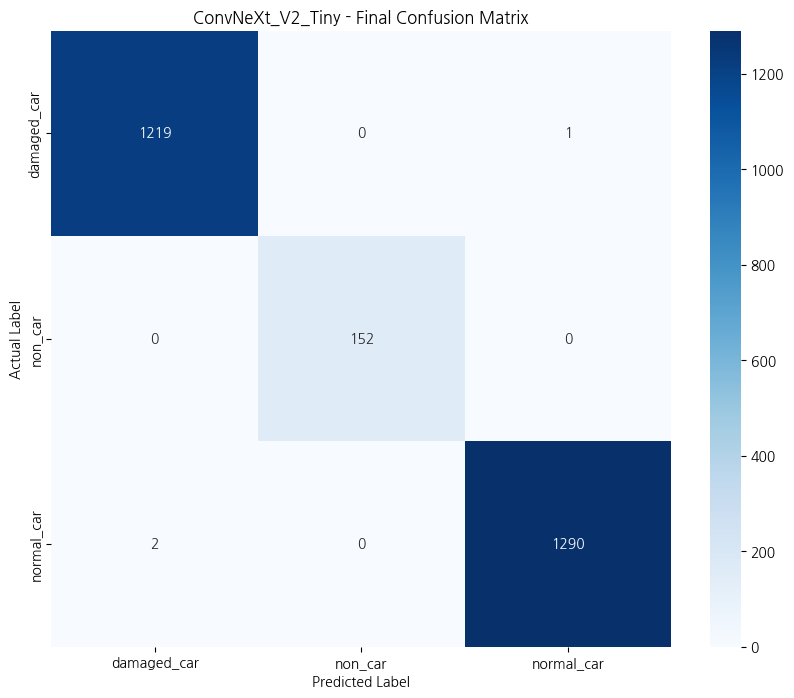

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import pandas as pd
import numpy as np

# 1. 최신 모델 라이브러리 설치
try:
    import timm
except ImportError:
    print("timm 라이브러리를 설치합니다...")
    !pip install timm
    import timm

# ==============================================================================
# ⚙️ [설정] 경로 및 하이퍼파라미터
# ==============================================================================
DRIVE_DIR = "/content/drive/MyDrive/03. HDMF/(share)HDMF_AUTO_SPOKE/DATA/DJ_FINAL_DATASET"
MODEL_NAME = "ConvNeXt_V2_Tiny"
SAVE_PATH = os.path.join(DRIVE_DIR, MODEL_NAME)
os.makedirs(SAVE_PATH, exist_ok=True)

DATA_DIR = "/content/classification_dataset"
BATCH_SIZE = 32
EPOCHS = 20
LR = 5e-5    # ConvNeXt 계열은 매우 낮은 학습률(Learning Rate)에서 안정적입니다.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================================================================
# 📦 [데이터] 전처리 (Augmentation 강화)
# ==============================================================================
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}
data_transforms['test'] = data_transforms['val']

image_datasets = {x: datasets.ImageFolder(os.path.join(DATA_DIR, x), data_transforms[x])
                  for x in ['train', 'val', 'test']}

dataloaders = {x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE,
                            shuffle=(x=='train'), num_workers=4, pin_memory=True)
               for x in ['train', 'val', 'test']}

class_names = image_datasets['train'].classes

# ==============================================================================
# 🏗️ [모델] ConvNeXt V2 설계 (FCMAE 가중치 활용)
# ==============================================================================
# 'tiny' 버전은 Colab 환경에서 속도와 성능의 밸런스가 가장 좋습니다.
model = timm.create_model('convnextv2_tiny.fcmae_ft_in22k_in1k', pretrained=True, num_classes=len(class_names))
model = model.to(DEVICE)

# ConvNeXt에 최적화된 AdamW 옵티마이저 사용
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ==============================================================================
# 🔥 [학습] 메인 트레이닝 루프
# ==============================================================================
best_acc = 0.0

print(f"🚀 {MODEL_NAME} 학습을 시작합니다. (Device: {DEVICE})")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for inputs, labels in dataloaders['train']:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    scheduler.step()

    # 검증(Validation)
    model.eval()
    val_corrects = 0
    with torch.no_grad():
        for inputs, labels in dataloaders['val']:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(image_datasets['train'])
    epoch_acc = val_corrects.double() / len(image_datasets['val'])

    print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {epoch_loss:.4f} | Val Acc: {epoch_acc:.4f}')

    if epoch_acc > best_acc:
        best_acc = epoch_acc
        torch.save(model.state_dict(), os.path.join(SAVE_PATH, 'best_model.pth'))

# ==============================================================================
# 📊 [평가] 최종 성능 검증 및 7대 지표 저장
# ==============================================================================
def final_evaluation():
    print("\n🔍 최종 성능 평가 및 리포트 생성을 시작합니다...")
    model.load_state_dict(torch.load(os.path.join(SAVE_PATH, 'best_model.pth')))
    model.eval()

    all_preds, all_labels = [], []
    inference_times = []

    # 정확한 FPS 측정을 위해 배치 사이즈 1로 테스트
    test_loader_fps = DataLoader(image_datasets['test'], batch_size=1, shuffle=False)

    with torch.no_grad():
        for inputs, labels in test_loader_fps:
            inputs = inputs.to(DEVICE)

            start_time = time.time()
            outputs = model(inputs)
            if torch.cuda.is_available(): torch.cuda.synchronize()
            inference_times.append(time.time() - start_time)

            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # 1. 지표 계산
    accuracy = (np.array(all_preds) == np.array(all_labels)).mean()
    f1 = f1_score(all_labels, all_preds, average='weighted')
    fps = 1 / np.mean(inference_times)
    params = sum(p.numel() for p in model.parameters()) / 1e6

    # 2. 결과 리포트 저장 (CSV)
    report_df = pd.DataFrame({
        "Metric": ["Model", "Accuracy", "F1-Score", "FPS", "Params (M)", "mAP50", "mAP50-95"],
        "Value": [MODEL_NAME, f"{accuracy:.4f}", f"{f1:.4f}", f"{fps:.2f}", f"{params:.2f}", "N/A(Cls)", "N/A(Cls)"]
    })
    report_df.to_csv(os.path.join(SAVE_PATH, "final_performance_report.csv"), index=False)

    # 3. Confusion Matrix 시각화 및 저장
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{MODEL_NAME} - Final Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.savefig(os.path.join(SAVE_PATH, "confusion_matrix.png"))

    print(f"\n" + "="*50)
    print(f"✅ {MODEL_NAME} 학습 및 평가 완료!")
    print(f"📂 결과 저장 경로: {SAVE_PATH}")
    print(f"🏆 Test Acc: {accuracy:.4f} | F1: {f1:.4f} | FPS: {fps:.2f}")
    print("="*50)

if __name__ == "__main__":
    final_evaluation()

📦 ConvNeXt V2 아키텍처를 생성합니다...
🔎 오탐 사례 수색 중 (이미지 수가 많으면 시간이 걸릴 수 있습니다)...
✅ 총 3개의 오탐 사례를 발견했습니다.


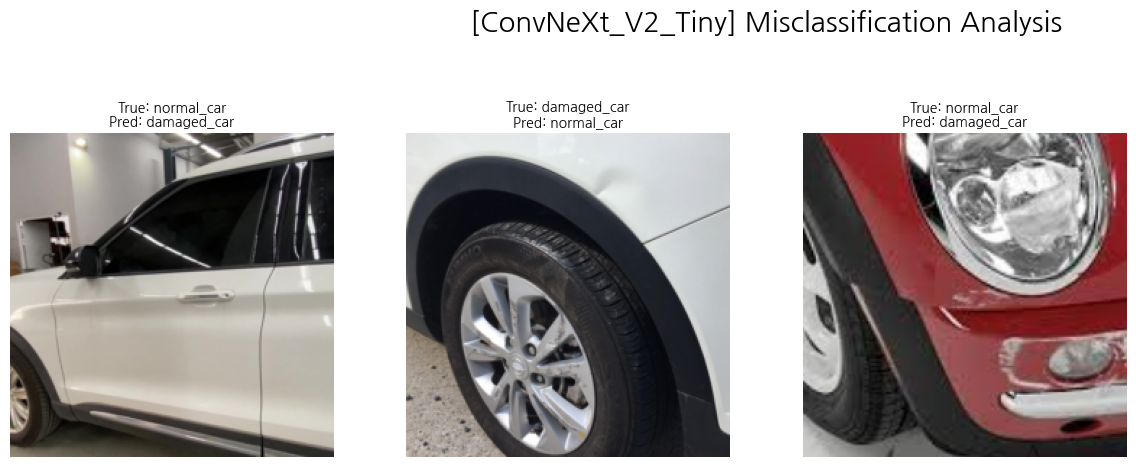

📂 분석 이미지가 저장되었습니다: /content/drive/MyDrive/03. HDMF/(share)HDMF_AUTO_SPOKE/DATA/DJ_FINAL_DATASET/ConvNeXt_V2_Tiny/misclassification_analysis.png


In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
import random

# timm 라이브러리 체크
try:
    import timm
except ImportError:
    !pip install timm
    import timm

# ==============================================================================
# ⚙️ [설정] 모델 경로 및 데이터 경로 (분석할 모델에 맞춰 수정하세요)
# ==============================================================================
DRIVE_DIR = "/content/drive/MyDrive/03. HDMF/(share)HDMF_AUTO_SPOKE/DATA/DJ_FINAL_DATASET"

# 1. ResNet50을 보고 싶다면: "ResNet50"
# 2. ConvNeXt를 보고 싶다면: "ConvNeXt_V2_Tiny"
MODEL_NAME = "ConvNeXt_V2_Tiny"

SAVE_PATH = os.path.join(DRIVE_DIR, MODEL_NAME)
DATA_DIR = "/content/classification_dataset/test"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================================================================
# 🛠️ [함수] 이미지 역정규화 (시각화용)
# ==============================================================================
def imshow(img, title):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(title, fontsize=10, color='red' if '!=' in title else 'black')
    plt.axis('off')

# ==============================================================================
# 🔍 [실행] 오탐 대상 검거 및 시각화
# ==============================================================================
def visualize_misclassified():
    # 1. 데이터 로더
    test_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    test_dataset = datasets.ImageFolder(DATA_DIR, test_transform)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
    class_names = test_dataset.classes

    # 2. 모델 아키텍처 동적 생성 (에러 해결 핵심!)
    if "ConvNeXt" in MODEL_NAME:
        print(f"📦 ConvNeXt V2 아키텍처를 생성합니다...")
        model = timm.create_model('convnextv2_tiny.fcmae_ft_in22k_in1k', pretrained=False, num_classes=len(class_names))
    else:
        print(f"📦 ResNet50 아키텍처를 생성합니다...")
        model = models.resnet50()
        model.fc = nn.Linear(model.fc.in_features, len(class_names))

    # 3. 가중치 로드
    weight_path = os.path.join(SAVE_PATH, 'best_model.pth')
    if not os.path.exists(weight_path):
        print(f"❌ 모델 파일을 찾을 수 없습니다: {weight_path}")
        return

    model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
    model = model.to(DEVICE)
    model.eval()

    misclassified_list = []

    print("🔎 오탐 사례 수색 중 (이미지 수가 많으면 시간이 걸릴 수 있습니다)...")
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            if preds[0] != labels[0]:
                misclassified_list.append((inputs.cpu()[0], labels.cpu().item(), preds.cpu().item()))

    print(f"✅ 총 {len(misclassified_list)}개의 오탐 사례를 발견했습니다.")

    # 4. 시각화
    num_to_show = min(len(misclassified_list), 12)
    if num_to_show == 0:
        print("🎉 모든 정답을 맞혔습니다!")
        return

    selected_samples = random.sample(misclassified_list, num_to_show)

    plt.figure(figsize=(16, 12))
    plt.suptitle(f"[{MODEL_NAME}] Misclassification Analysis", fontsize=20)

    for i, (img, true_idx, pred_idx) in enumerate(selected_samples):
        plt.subplot(3, 4, i + 1)
        title = f"True: {class_names[true_idx]}\nPred: {class_names[pred_idx]}"
        imshow(img, title)

    analysis_save_path = os.path.join(SAVE_PATH, "misclassification_analysis.png")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(analysis_save_path)
    plt.show()
    print(f"📂 분석 이미지가 저장되었습니다: {analysis_save_path}")

if __name__ == "__main__":
    visualize_misclassified()

## 4.3 yolo v8 (이미지 분류 모드 (Classification: yolov8n-cls.pt)

In [6]:
#!pip install ultralytics

🚀 YOLOv8_Classification 학습을 시작합니다...
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/classification_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_results, nbs=64, nms=False, opset=None, optimize=False, optimizer=aut

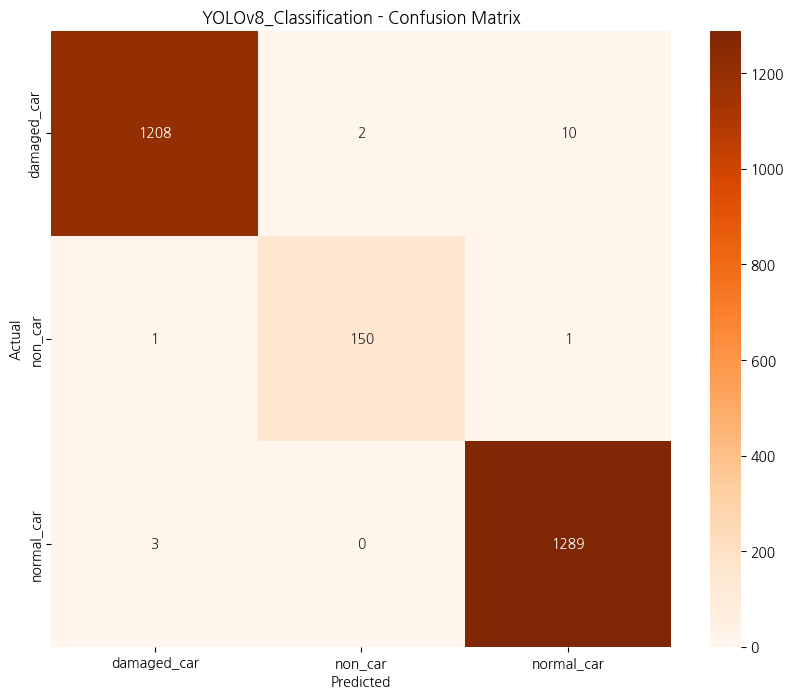

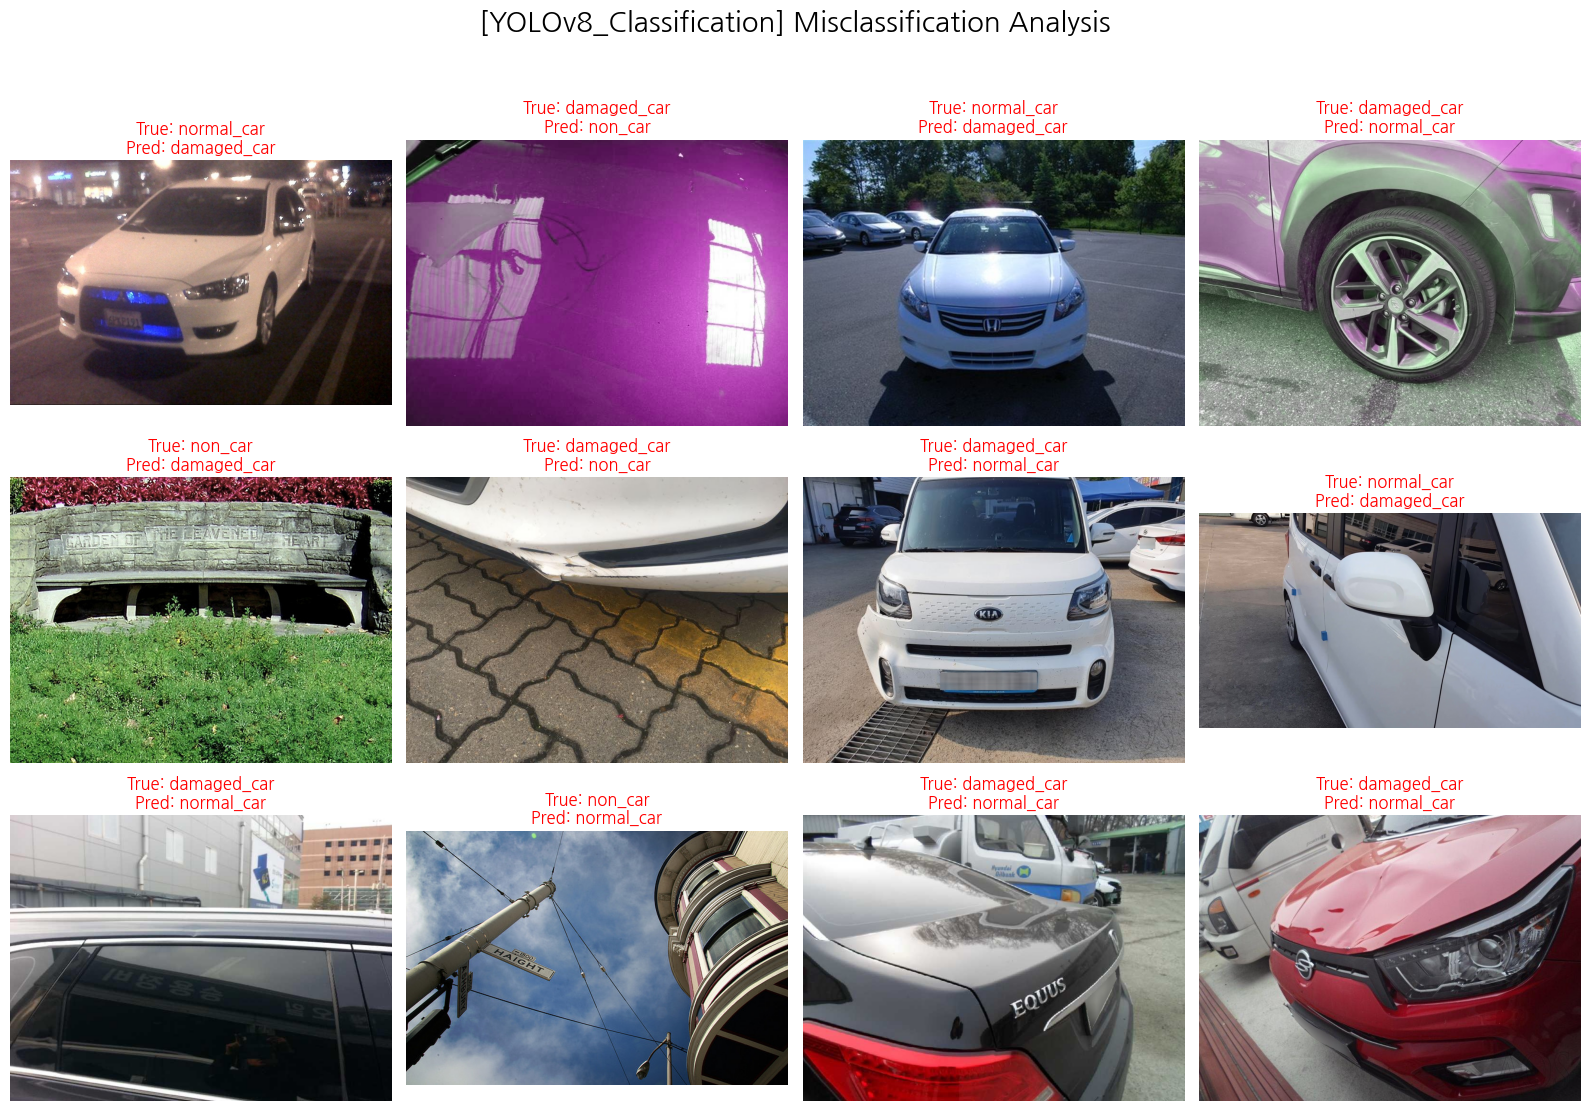

📂 오탐 분석 이미지가 저장되었습니다: /content/drive/MyDrive/03. HDMF/(share)HDMF_AUTO_SPOKE/DATA/DJ_FINAL_DATASET/YOLOv8_Classification/misclassification_analysis.png


In [16]:
import os
import time
import random
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from torchvision import datasets

try:
    from ultralytics import YOLO
except ImportError:
    !pip install ultralytics
    from ultralytics import YOLO

# ==============================================================================
# ⚙️ [설정] 경로 지정 및 하이퍼파라미터
# ==============================================================================
# 분류용 데이터셋 경로 (train, val, test 폴더 내에 클래스별 폴더가 있는 구조)
DATA_DIR = "/content/classification_dataset"
DRIVE_DIR = "/content/drive/MyDrive/03. HDMF/(share)HDMF_AUTO_SPOKE/DATA/DJ_FINAL_DATASET"

MODEL_NAME = "YOLOv8_Classification"
SAVE_PATH = os.path.join(DRIVE_DIR, MODEL_NAME)
os.makedirs(SAVE_PATH, exist_ok=True)

EPOCHS = 20
IMG_SIZE = 224 # 분류 모델의 표준 이미지 사이즈

# ==============================================================================
# 🔥 [1단계] YOLOv8 분류 모델 학습
# ==============================================================================
def train_yolo_cls():
    print(f"🚀 {MODEL_NAME} 학습을 시작합니다...")
    # 분류용 가장 가벼운 Nano 모델 로드
    model = YOLO('yolov8n-cls.pt')

    # YOLO는 폴더 구조를 자동으로 인식합니다.
    model.train(
        data=DATA_DIR,
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        project=SAVE_PATH,
        name="train_results",
        exist_ok=True,
        device=0 if torch.cuda.is_available() else 'cpu'
    )
    print(f"✅ 학습 완료! 가중치가 저장되었습니다.")

# ==============================================================================
# 📊 [2단계] 테스트셋 성능 검증 (Accuracy, F1, FPS 등)
# ==============================================================================
def evaluate_yolo_cls():
    print("\n🔍 최종 성능 평가 및 지표 추출을 시작합니다...")
    best_weight_path = os.path.join(SAVE_PATH, "train_results", "weights", "best.pt")

    if not os.path.exists(best_weight_path):
        print("❌ 모델 가중치 파일을 찾을 수 없습니다.")
        return None, None

    best_model = YOLO(best_weight_path)

    # 평가를 위해 PyTorch ImageFolder를 활용하여 정답 라벨과 이미지 경로를 가져옵니다.
    test_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'))
    class_names = test_dataset.classes

    all_preds, all_labels = [], []
    inference_times = []
    misclassified_list = []

    print(f"테스트 데이터({len(test_dataset)}장) 추론 중...")

    for img_path, true_idx in test_dataset.samples:
        # ⏱️ 추론 속도 측정
        start_time = time.time()
        results = best_model.predict(img_path, imgsz=IMG_SIZE, verbose=False)
        if torch.cuda.is_available(): torch.cuda.synchronize()
        inference_times.append(time.time() - start_time)

        # 예측값 추출 (top1 확률을 가진 클래스 인덱스)
        pred_idx = results[0].probs.top1

        all_preds.append(pred_idx)
        all_labels.append(true_idx)

        # 오탐 수집
        if pred_idx != true_idx:
            misclassified_list.append((img_path, class_names[true_idx], class_names[pred_idx]))

    # 1. 지표 계산
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    fps = 1 / np.mean(inference_times)
    params = sum(p.numel() for p in best_model.model.parameters()) / 1e6

    # 2. 결과 리포트 CSV 저장
    report_df = pd.DataFrame({
        "Metric": ["Model", "Accuracy", "F1-Score", "FPS", "Params (M)", "mAP50", "mAP50-95"],
        "Value": [MODEL_NAME, f"{acc:.4f}", f"{f1:.4f}", f"{fps:.2f}", f"{params:.2f}", "N/A(Cls)", "N/A(Cls)"]
    })
    report_df.to_csv(os.path.join(SAVE_PATH, "final_performance_report.csv"), index=False)

    # 3. Confusion Matrix 시각화
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{MODEL_NAME} - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.savefig(os.path.join(SAVE_PATH, "confusion_matrix.png"))

    print(f"\n🏆 [YOLOv8 Classification 평가 요약]")
    print(f"  - Accuracy: {acc*100:.2f}%")
    print(f"  - F1-Score: {f1:.4f}")
    print(f"  - FPS: {fps:.2f}")
    print(f"  - Parameters: {params:.2f} M")

    return misclassified_list, class_names

# ==============================================================================
# 🕵️‍♂️ [3단계] 오탐 대상 시각화
# ==============================================================================
def visualize_misclassified(misclassified_list, class_names, num_samples=12):
    if not misclassified_list:
        print("\n🎉 완벽합니다! 오탐이 하나도 없습니다.")
        return

    print(f"\n🔎 총 {len(misclassified_list)}개의 오탐 사례 중 일부를 시각화합니다...")

    # 무작위 샘플링
    samples = random.sample(misclassified_list, min(len(misclassified_list), num_samples))

    plt.figure(figsize=(16, 12))
    plt.suptitle(f"[{MODEL_NAME}] Misclassification Analysis", fontsize=20)

    for i, (img_path, true_lbl, pred_lbl) in enumerate(samples):
        img = Image.open(img_path).convert('RGB')
        plt.subplot(3, 4, i + 1)
        plt.imshow(img)
        title = f"True: {true_lbl}\nPred: {pred_lbl}"
        plt.title(title, fontsize=12, color='red')
        plt.axis('off')

    analysis_save_path = os.path.join(SAVE_PATH, "misclassification_analysis.png")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(analysis_save_path)
    plt.show()
    print(f"📂 오탐 분석 이미지가 저장되었습니다: {analysis_save_path}")

# ==============================================================================
# 🚀 실행
# ==============================================================================
if __name__ == "__main__":
    train_yolo_cls()  # 1. 모델 학습
    mis_list, classes = evaluate_yolo_cls()  # 2. 성능 검증
    if mis_list:
        visualize_misclassified(mis_list, classes)  # 3. 오탐 시각화

## 4.4 RT-DETR

In [ ]:
import os
import time
import random
import yaml
import torch
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    from ultralytics import RTDETR # YOLO 대신 RTDETR 로드!
except ImportError:
    !pip install ultralytics
    from ultralytics import RTDETR

# ==============================================================================
# ⚙️ [설정] 경로 지정
# ==============================================================================
DATA_DIR = "/content/split_dataset" # 이전 단계에서 만든 txt 라벨이 포함된 폴더
DRIVE_DIR = "/content/drive/MyDrive/03. HDMF/(share)HDMF_AUTO_SPOKE/DATA/DJ_FINAL_DATASET"

MODEL_NAME = "RT_DETR_Detection"
SAVE_PATH = os.path.join(DRIVE_DIR, MODEL_NAME)
os.makedirs(SAVE_PATH, exist_ok=True)
YAML_PATH = os.path.join(SAVE_PATH, "data.yaml")

EPOCHS = 20
IMG_SIZE = 640

# ==============================================================================
# 📝 [0단계] RT-DETR용 data.yaml 생성
# ==============================================================================
yaml_data = {
    'train': os.path.join(DATA_DIR, 'train', 'images'),
    'val': os.path.join(DATA_DIR, 'val', 'images'),
    'test': os.path.join(DATA_DIR, 'test', 'images'),
    'nc': 3,
    'names': ['normal_car', 'damaged_car', 'non_car']
}

with open(YAML_PATH, 'w') as f:
    yaml.dump(yaml_data, f)
print(f"✅ YAML 파일 생성 완료: {YAML_PATH}")

# ==============================================================================
# 🔥 [1단계] RT-DETR 모델 학습
# ==============================================================================
print(f"🚀 RT-DETR Detection 학습 시작... (Transformer의 힘을 느껴보세요!)")

# rtdetr-l.pt (Large 모델) 기본 로드
# 좀 더 가벼운 걸 원하시면 rtdetr-resnet50.pt 로 변경 가능합니다.
model = RTDETR('rtdetr-l.pt')

results = model.train(
    data=YAML_PATH,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    project=SAVE_PATH,
    name="train_results",
    exist_ok=True,
    device=0 if torch.cuda.is_available() else 'cpu'
)

BEST_WEIGHT_PATH = os.path.join(SAVE_PATH, "train_results", "weights", "best.pt")

# ==============================================================================
# 📊 [2단계] 테스트셋 성능 검증 (mAP, F1, FPS)
# ==============================================================================
def evaluate_detection_rtdetr():
    print("\n🔍 테스트셋 최종 성능 평가 시작...")
    eval_model = RTDETR(BEST_WEIGHT_PATH)

    # 1. 내장 val 함수로 mAP 및 F1 추출
    metrics = eval_model.val(data=YAML_PATH, split='test', project=SAVE_PATH, name="test_results", exist_ok=True)
    map50 = metrics.box.map50
    map95 = metrics.box.map
    f1_scores = metrics.box.f1
    mean_f1 = np.mean(f1_scores) if len(f1_scores) > 0 else 0.0

    # 2. FPS 측정 (100장 기준)
    test_img_dir = os.path.join(DATA_DIR, 'test', 'images')
    test_imgs = [os.path.join(test_img_dir, f) for f in os.listdir(test_img_dir) if f.endswith(('.jpg', '.png'))]

    inference_times = []
    for img_path in test_imgs[:100]:
        start_time = time.time()
        eval_model.predict(img_path, imgsz=IMG_SIZE, verbose=False)
        if torch.cuda.is_available(): torch.cuda.synchronize()
        inference_times.append(time.time() - start_time)

    fps = 1 / np.mean(inference_times)

## 4.5 ViT

In [17]:
pip install timm

📦 ViT_Tiny_Classification 모델을 준비합니다...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

🚀 학습 시작... (Device: cuda)
Epoch 1/20 | Loss: 0.1240 | Val Acc: 0.9865
Epoch 2/20 | Loss: 0.0519 | Val Acc: 0.9914
Epoch 3/20 | Loss: 0.0420 | Val Acc: 0.9914
Epoch 4/20 | Loss: 0.0324 | Val Acc: 0.9951
Epoch 5/20 | Loss: 0.0282 | Val Acc: 0.9955
Epoch 6/20 | Loss: 0.0237 | Val Acc: 0.9891
Epoch 7/20 | Loss: 0.0210 | Val Acc: 0.9940
Epoch 8/20 | Loss: 0.0185 | Val Acc: 0.9884
Epoch 9/20 | Loss: 0.0155 | Val Acc: 0.9966
Epoch 10/20 | Loss: 0.0149 | Val Acc: 0.9955
Epoch 11/20 | Loss: 0.0152 | Val Acc: 0.9981
Epoch 12/20 | Loss: 0.0106 | Val Acc: 0.9981
Epoch 13/20 | Loss: 0.0108 | Val Acc: 0.9985
Epoch 14/20 | Loss: 0.0077 | Val Acc: 0.9977
Epoch 15/20 | Loss: 0.0059 | Val Acc: 0.9985
Epoch 16/20 | Loss: 0.0053 | Val Acc: 0.9989
Epoch 17/20 | Loss: 0.0048 | Val Acc: 0.9985
Epoch 18/20 | Loss: 0.0051 | Val Acc: 0.9985
Epoch 19/20 | Loss: 0.0058 | Val Acc: 0.9992
Epoch 20/20 | Loss: 0.0034 | Val Acc: 0.9992

🔍 최종 성능 평가 및 지표 추출을 시작합니다...

🏆 [ViT 평가 요약]
  - Accuracy: 99.85%
  - F1-Score: 0.9

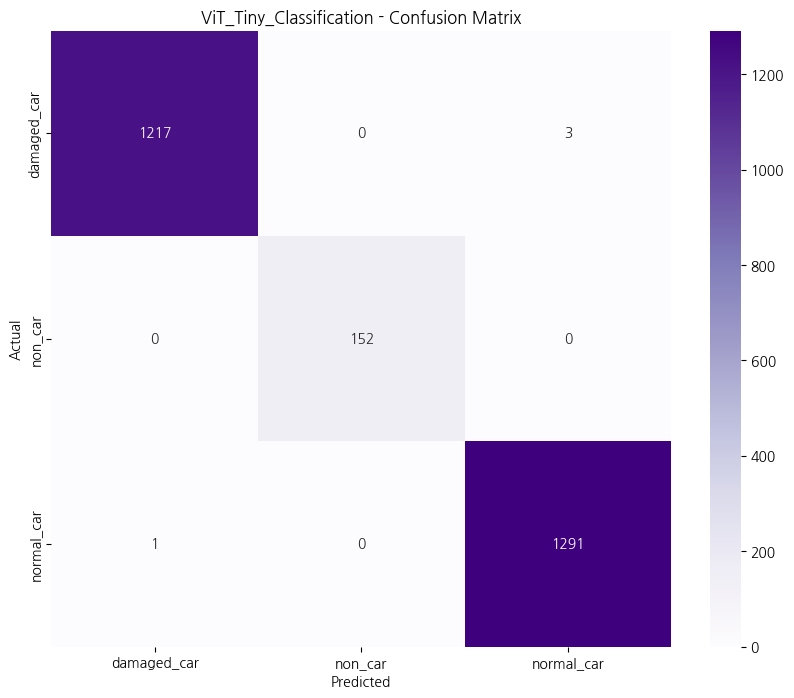

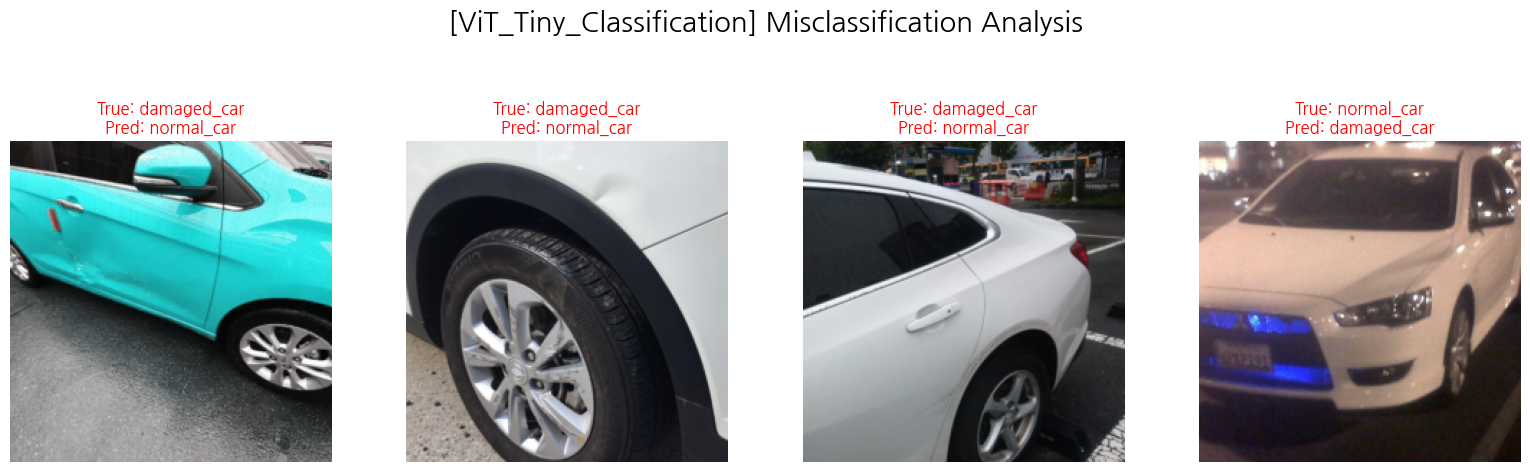

📂 오탐 분석 이미지가 저장되었습니다: /content/drive/MyDrive/03. HDMF/(share)HDMF_AUTO_SPOKE/DATA/DJ_FINAL_DATASET/ViT_Tiny_Classification/misclassification_analysis.png


In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import pandas as pd
import numpy as np
import random

# timm 라이브러리 설치 확인
try:
    import timm
except ImportError:
    print("timm 라이브러리를 설치합니다...")
    os.system('pip install timm')
    import timm

# ==============================================================================
# ⚙️ [설정] 경로 및 하이퍼파라미터
# ==============================================================================
DATA_DIR = "/content/classification_dataset"  # 분류용 데이터셋 경로
DRIVE_DIR = "/content/drive/MyDrive/03. HDMF/(share)HDMF_AUTO_SPOKE/DATA/DJ_FINAL_DATASET"

MODEL_NAME = "ViT_Tiny_Classification"
SAVE_PATH = os.path.join(DRIVE_DIR, MODEL_NAME)
os.makedirs(SAVE_PATH, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 20
LR = 3e-5  # 트랜스포머는 CNN보다 낮은 학습률(Learning Rate)에서 잘 학습됩니다.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================================================================
# 📦 [데이터] 전처리 및 로더 (ViT 표준 입력 규격 224x224)
# ==============================================================================
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}
data_transforms['test'] = data_transforms['val']

image_datasets = {x: datasets.ImageFolder(os.path.join(DATA_DIR, x), data_transforms[x]) for x in ['train', 'val', 'test']}

# num_workers는 코랩 환경에 맞춰 안전하게 2로 설정합니다.
dataloaders = {x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE, shuffle=(x=='train'), num_workers=2, pin_memory=True) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

# ==============================================================================
# 🏗️ [모델] ViT 아키텍처 로드
# ==============================================================================
print(f"📦 {MODEL_NAME} 모델을 준비합니다...")
# 가장 가볍고 빠른 tiny 모델 사용 (패치 사이즈 16)
model = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=len(class_names))
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
# 트랜스포머 모델의 국룰 조합: AdamW + CosineAnnealingLR
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ==============================================================================
# 🔥 [1단계] 메인 학습 루프
# ==============================================================================
def train_model():
    print(f"🚀 학습 시작... (Device: {DEVICE})")
    best_acc = 0.0

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0

        for inputs, labels in dataloaders['train']:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        scheduler.step()

        # 검증(Validation)
        model.eval()
        val_corrects = 0
        with torch.no_grad():
            for inputs, labels in dataloaders['val']:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(image_datasets['train'])
        epoch_acc = val_corrects.double() / len(image_datasets['val'])

        print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {epoch_loss:.4f} | Val Acc: {epoch_acc:.4f}')

        if epoch_acc > best_acc:
            best_acc = epoch_acc
            torch.save(model.state_dict(), os.path.join(SAVE_PATH, 'best_model.pth'))

# ==============================================================================
# 📊 [2단계] 성능 검증 및 지표 추출
# ==============================================================================
def evaluate_model():
    print("\n🔍 최종 성능 평가 및 지표 추출을 시작합니다...")
    model.load_state_dict(torch.load(os.path.join(SAVE_PATH, 'best_model.pth')))
    model.eval()

    all_preds, all_labels = [], []
    inference_times = []
    misclassified_list = []

    # FPS 측정을 위해 배치 사이즈 1로 테스트
    test_loader_fps = DataLoader(image_datasets['test'], batch_size=1, shuffle=False)

    with torch.no_grad():
        for inputs, labels in test_loader_fps:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            start_time = time.time()
            outputs = model(inputs)
            if torch.cuda.is_available(): torch.cuda.synchronize()
            inference_times.append(time.time() - start_time)

            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # 오탐 수집
            if preds[0] != labels[0]:
                misclassified_list.append((inputs.cpu()[0], labels.cpu().item(), preds.cpu().item()))

    # 1. 7대 지표 계산
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    fps = 1 / np.mean(inference_times)
    params = sum(p.numel() for p in model.parameters()) / 1e6

    report_df = pd.DataFrame({
        "Metric": ["Model", "Accuracy", "F1-Score", "FPS", "Params (M)", "mAP50", "mAP50-95"],
        "Value": [MODEL_NAME, f"{acc:.4f}", f"{f1:.4f}", f"{fps:.2f}", f"{params:.2f}", "N/A(Cls)", "N/A(Cls)"]
    })
    report_df.to_csv(os.path.join(SAVE_PATH, "final_performance_report.csv"), index=False)

    # 2. Confusion Matrix 시각화
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{MODEL_NAME} - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.savefig(os.path.join(SAVE_PATH, "confusion_matrix.png"))

    print(f"\n🏆 [ViT 평가 요약]")
    print(f"  - Accuracy: {acc*100:.2f}%")
    print(f"  - F1-Score: {f1:.4f}")
    print(f"  - FPS: {fps:.2f}")
    print(f"  - Parameters: {params:.2f} M")

    return misclassified_list

# ==============================================================================
# 🕵️‍♂️ [3단계] 오탐 대상 시각화
# ==============================================================================
def visualize_errors(misclassified_list, num_samples=12):
    if not misclassified_list:
        print("\n🎉 오탐이 하나도 없습니다!")
        return

    print(f"\n🔎 총 {len(misclassified_list)}개의 오탐 사례 중 일부를 시각화합니다...")
    samples = random.sample(misclassified_list, min(len(misclassified_list), num_samples))

    plt.figure(figsize=(16, 12))
    plt.suptitle(f"[{MODEL_NAME}] Misclassification Analysis", fontsize=20)

    for i, (img_tensor, true_idx, pred_idx) in enumerate(samples):
        # 텐서를 이미지로 역정규화
        img = img_tensor.numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        plt.subplot(3, 4, i + 1)
        plt.imshow(img)
        title = f"True: {class_names[true_idx]}\nPred: {class_names[pred_idx]}"
        plt.title(title, fontsize=12, color='red')
        plt.axis('off')

    analysis_save_path = os.path.join(SAVE_PATH, "misclassification_analysis.png")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(analysis_save_path)
    plt.show()
    print(f"📂 오탐 분석 이미지가 저장되었습니다: {analysis_save_path}")

# ==============================================================================
# 🚀 실행
# ==============================================================================
if __name__ == "__main__":
    train_model()
    mis_list = evaluate_model()
    if mis_list:
        visualize_errors(mis_list)

## 4.6 Swin Transformer V2

📦 Swin_V2_Tiny_Classification 모델을 준비합니다... (256x256 해상도 최적화)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

🚀 학습 시작... (Device: cuda)
Epoch 1/20 | Loss: 0.0767 | Val Acc: 0.9932
Epoch 2/20 | Loss: 0.0224 | Val Acc: 0.9970
Epoch 3/20 | Loss: 0.0174 | Val Acc: 0.9966
Epoch 4/20 | Loss: 0.0151 | Val Acc: 0.9974
Epoch 5/20 | Loss: 0.0110 | Val Acc: 0.9989
Epoch 6/20 | Loss: 0.0127 | Val Acc: 0.9974
Epoch 7/20 | Loss: 0.0097 | Val Acc: 0.9981
Epoch 8/20 | Loss: 0.0060 | Val Acc: 0.9992
Epoch 9/20 | Loss: 0.0060 | Val Acc: 0.9989
Epoch 10/20 | Loss: 0.0067 | Val Acc: 0.9992
Epoch 11/20 | Loss: 0.0035 | Val Acc: 0.9992
Epoch 12/20 | Loss: 0.0058 | Val Acc: 0.9992
Epoch 13/20 | Loss: 0.0024 | Val Acc: 0.9989
Epoch 14/20 | Loss: 0.0026 | Val Acc: 0.9996
Epoch 15/20 | Loss: 0.0024 | Val Acc: 0.9996
Epoch 16/20 | Loss: 0.0029 | Val Acc: 1.0000
Epoch 17/20 | Loss: 0.0011 | Val Acc: 0.9996
Epoch 18/20 | Loss: 0.0016 | Val Acc: 0.9992
Epoch 19/20 | Loss: 0.0016 | Val Acc: 0.9996
Epoch 20/20 | Loss: 0.0018 | Val Acc: 0.9996

🔍 최종 성능 평가 및 지표 추출을 시작합니다...

🏆 [Swin V2 평가 요약]
  - Accuracy: 99.96%
  - F1-Score:

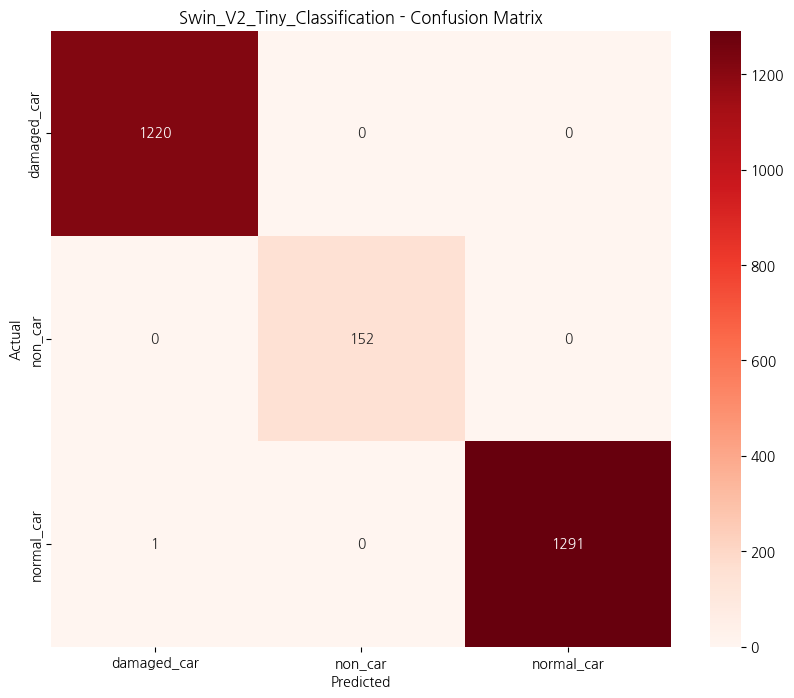

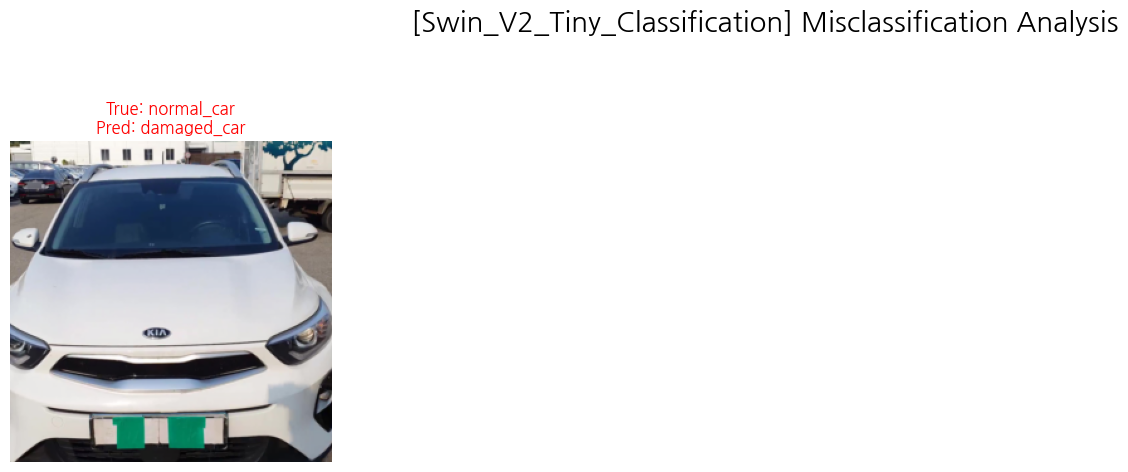

📂 오탐 분석 이미지가 저장되었습니다: /content/drive/MyDrive/03. HDMF/(share)HDMF_AUTO_SPOKE/DATA/DJ_FINAL_DATASET/Swin_V2_Tiny_Classification/misclassification_analysis.png


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import pandas as pd
import numpy as np
import random

try:
    import timm
except ImportError:
    print("timm 라이브러리를 설치합니다...")
    os.system('pip install timm')
    import timm

# ==============================================================================
# ⚙️ [설정] 경로 및 하이퍼파라미터
# ==============================================================================
DATA_DIR = "/content/classification_dataset"
DRIVE_DIR = "/content/drive/MyDrive/03. HDMF/(share)HDMF_AUTO_SPOKE/DATA/DJ_FINAL_DATASET"

MODEL_NAME = "Swin_V2_Tiny_Classification"
SAVE_PATH = os.path.join(DRIVE_DIR, MODEL_NAME)
os.makedirs(SAVE_PATH, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 20
LR = 3e-5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================================================================
# 📦 [데이터] 전처리 및 로더 (Swin V2 표준 입력 규격 256x256으로 수정 🌟)
# ==============================================================================
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(256), # 224 -> 256 변경
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(288),            # 여유 있게 리사이즈 후
        transforms.CenterCrop(256),        # 256으로 크롭
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}
data_transforms['test'] = data_transforms['val']

image_datasets = {x: datasets.ImageFolder(os.path.join(DATA_DIR, x), data_transforms[x]) for x in ['train', 'val', 'test']}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE, shuffle=(x=='train'), num_workers=2, pin_memory=True) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

# ==============================================================================
# 🏗️ [모델] Swin V2 아키텍처 로드 (정확한 모델명으로 수정 🌟)
# ==============================================================================
print(f"📦 {MODEL_NAME} 모델을 준비합니다... (256x256 해상도 최적화)")
# 정확한 timm 모델명: swinv2_tiny_window8_256
model = timm.create_model('swinv2_tiny_window8_256', pretrained=True, num_classes=len(class_names))
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ==============================================================================
# 🔥 [1단계] 메인 학습 루프
# ==============================================================================
def train_model():
    print(f"🚀 학습 시작... (Device: {DEVICE})")
    best_acc = 0.0

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0

        for inputs, labels in dataloaders['train']:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        scheduler.step()

        model.eval()
        val_corrects = 0
        with torch.no_grad():
            for inputs, labels in dataloaders['val']:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(image_datasets['train'])
        epoch_acc = val_corrects.double() / len(image_datasets['val'])

        print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {epoch_loss:.4f} | Val Acc: {epoch_acc:.4f}')

        if epoch_acc > best_acc:
            best_acc = epoch_acc
            torch.save(model.state_dict(), os.path.join(SAVE_PATH, 'best_model.pth'))

# ==============================================================================
# 📊 [2단계] 성능 검증 및 지표 추출
# ==============================================================================
def evaluate_model():
    print("\n🔍 최종 성능 평가 및 지표 추출을 시작합니다...")
    model.load_state_dict(torch.load(os.path.join(SAVE_PATH, 'best_model.pth')))
    model.eval()

    all_preds, all_labels = [], []
    inference_times = []
    misclassified_list = []

    test_loader_fps = DataLoader(image_datasets['test'], batch_size=1, shuffle=False)

    with torch.no_grad():
        for inputs, labels in test_loader_fps:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            start_time = time.time()
            outputs = model(inputs)
            if torch.cuda.is_available(): torch.cuda.synchronize()
            inference_times.append(time.time() - start_time)

            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            if preds[0] != labels[0]:
                misclassified_list.append((inputs.cpu()[0], labels.cpu().item(), preds.cpu().item()))

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    fps = 1 / np.mean(inference_times)
    params = sum(p.numel() for p in model.parameters()) / 1e6

    report_df = pd.DataFrame({
        "Metric": ["Model", "Accuracy", "F1-Score", "FPS", "Params (M)", "mAP50", "mAP50-95"],
        "Value": [MODEL_NAME, f"{acc:.4f}", f"{f1:.4f}", f"{fps:.2f}", f"{params:.2f}", "N/A(Cls)", "N/A(Cls)"]
    })
    report_df.to_csv(os.path.join(SAVE_PATH, "final_performance_report.csv"), index=False)

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{MODEL_NAME} - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.savefig(os.path.join(SAVE_PATH, "confusion_matrix.png"))

    print(f"\n🏆 [Swin V2 평가 요약]")
    print(f"  - Accuracy: {acc*100:.2f}%")
    print(f"  - F1-Score: {f1:.4f}")
    print(f"  - FPS: {fps:.2f}")
    print(f"  - Parameters: {params:.2f} M")

    return misclassified_list

# ==============================================================================
# 🕵️‍♂️ [3단계] 오탐 대상 시각화
# ==============================================================================
def visualize_errors(misclassified_list, num_samples=12):
    if not misclassified_list:
        print("\n🎉 오탐이 하나도 없습니다!")
        return

    print(f"\n🔎 총 {len(misclassified_list)}개의 오탐 사례 중 일부를 시각화합니다...")
    samples = random.sample(misclassified_list, min(len(misclassified_list), num_samples))

    plt.figure(figsize=(16, 12))
    plt.suptitle(f"[{MODEL_NAME}] Misclassification Analysis", fontsize=20)

    for i, (img_tensor, true_idx, pred_idx) in enumerate(samples):
        img = img_tensor.numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        plt.subplot(3, 4, i + 1)
        plt.imshow(img)
        title = f"True: {class_names[true_idx]}\nPred: {class_names[pred_idx]}"
        plt.title(title, fontsize=12, color='red')
        plt.axis('off')

    analysis_save_path = os.path.join(SAVE_PATH, "misclassification_analysis.png")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(analysis_save_path)
    plt.show()
    print(f"📂 오탐 분석 이미지가 저장되었습니다: {analysis_save_path}")

# ==============================================================================
# 🚀 실행
# ==============================================================================
if __name__ == "__main__":
    train_model()
    mis_list = evaluate_model()
    if mis_list:
        visualize_errors(mis_list)